# B2B Chemical Procurement Price Forecasting
**Thesis code — Huong Thao Bui (639485).** Run top-to-bottom (`Kernel → Restart & Run All`). Requires `Full Data.xlsx` in the same folder.

Structure: Setup → Data → EDA (Ch.3) → Function definitions → Results → Appendix.

## 1. Setup

In [1]:
pip install pandas matplotlib seaborn openpyxl scikit-learn xgboost shap statsmodels


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Consolidated imports (run once)
import warnings
warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
import shap


## 2. Data loading and preprocessing

In [3]:
# Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Load the data
file_path = 'Full Data.xlsx' 
df = pd.read_excel(file_path)

In [4]:
product_cols = [
    'NPEL-128E (24000kg/tank)', 
    'NPEF-164X (220kg/drum)', 
    'NPES-902 (25kg/bag)', 
    'NPCN-704 (20kg/bag)'
]
for col in product_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

macro_cols = [
    'Aromatics (Benzene) PPI', 
    'Brent Crude Oil Price (USD)', 
    'Taiwan Export Unit Price (USD)',
    'Deep Sea Freight PPI', 
    'EUR-USD Exchange Rate', 
    'Euro Area Industrial Production',
    '3-month EURIBOR', 
    'China Caixin Manufacturing PMI', 
    'TAIEX',
    'Nan Ya Stock Price (TWD)', 
    'GSCI Commodities Index',
    'European Economic Policy Uncertainty Index', 
    'NASDAQ',
    'Equity Market Volatility Tracker: Commodity Markets'
]

plt.style.use('seaborn-v0_8-whitegrid')

In [5]:
def _is_stationary(series, alpha=0.05):
    """Stationary only if ADF REJECTS a unit root AND KPSS FAILS to reject
    stationarity (the same 5% rule used in Appendix J)."""
    s = series.dropna()
    try:
        adf_p = adfuller(s, autolag='AIC')[1]
    except Exception:
        adf_p = 1.0
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_p = kpss(s, regression='c', nlags='auto')[1]
    except Exception:
        kpss_p = 0.0
    return (adf_p < alpha) and (kpss_p > alpha)


def load_and_preprocess_uniform(filepath,
                                 targets=None,
                                 excluded_macros=None,
                                 start='2011-07-01',
                                 alpha=0.05):
    if targets is None:
        targets = ['NPEL-128E', 'NPEF-164X', 'NPES-902', 'NPCN-704']
    if excluded_macros is None:
        excluded_macros = ['Aromatics (Benzene) PPI', 'TAIEX',
                           'GSCI Commodities Index']

    df = (pd.read_excel(filepath, parse_dates=['Date'])
            .set_index('Date').sort_index())

    # Raw target headers carry a packaging suffix, e.g. "NPEL-128E (24000kg/tank)".
    # Rename to the short codes the rest of the pipeline uses (your
    # split(' ')[0] convention) so df['NPEL-128E'] etc. exist. <-- fixes KeyError
    df = df.rename(columns={c: c.split(' ')[0] for c in df.columns
                            if c.split(' ')[0] in targets})

    macro_features = [c for c in df.columns
                      if c not in targets and c not in excluded_macros]

    work = pd.DataFrame(index=df.index)

    # 1) difference EVERY macro; stationarity is used only to flag the two series that are overdifferenced by this uniform choice.
    transform_log = {}
    for c in macro_features:
        was_stationary = _is_stationary(df[c], alpha)
        work[c] = df[c].diff()
        transform_log[c] = 'diff (overdifferenced)' if was_stationary else 'diff'

    # 2) standardise macro features (NaN-safe; ddof=0 matches StandardScaler). Global scaling kept for parity: OLS/XGBoost are scale-invariant, and the penalised models in Cell 4 re-scale within their own train folds.
    for c in macro_features:
        sd = work[c].std(ddof=0)
        work[c] = (work[c] - work[c].mean()) / (sd if sd and sd != 0 else 1.0)

    # 3) carry targets through in LEVELS (model functions difference them internally and reconstruct absolute prices from the prior level)
    for t in targets:
        work[t] = df[t]

    # 4) lags. Macros: t-1..t-3. Target anchors: lag of the differenced target (lagged CHANGE, not lagged level) so the cross-learning inputs match the differenced target's integration order.
    feature_cols = []
    for c in macro_features:
        for lag in (1, 2, 3):
            name = f"{c}_lag{lag}"
            work[name] = work[c].shift(lag)
            feature_cols.append(name)
    for t in targets:
        name = f"{t}_lag1"
        work[name] = df[t].diff().shift(1)
        feature_cols.append(name)

    # 5) drop raw macro levels, align, trim warm-up rows
    work = work.drop(columns=macro_features)
    work = work.loc[start:].dropna()

    print("Transform decisions (levels test -> action):")
    for c, v in transform_log.items():
        print(f"   {c:48s} -> {v}")
    n_over = sum('overdifferenced' in v for v in transform_log.values())
    print(f"\nDifferenced ALL {len(transform_log)} macros "
          f"({n_over} of them overdifferenced by the uniform choice).")
    print(f"Final shape: {work.shape} | feature count: {len(feature_cols)}")
    return work, targets, feature_cols, transform_log


# OLS with interaction terms
def run_corrected_tiered_ols_baseline(df_clean, target_cols):
    """4-tier OLS ablation with multiplicative portfolio interactions."""
    results = []
    df_stat = df_clean.copy()
    for col in target_cols:
        df_stat[f"{col}_diff"] = df_stat[col].diff()
    df_stat.dropna(inplace=True)
    split_idx = int(len(df_stat) * 0.8)

    for target in target_cols:
        anchor_lag = f"{target}_lag1"
        target_diff = f"{target}_diff"
        other_resin_lags = [f"{t}_lag1" for t in target_cols if t != target]

        all_features = [c for c in df_stat.columns
                        if c not in target_cols and not c.endswith('_diff')]
        macro_lags = [c for c in all_features
                      if c not in other_resin_lags and c != anchor_lag]

        X_full = df_stat[macro_lags + [anchor_lag] + other_resin_lags].copy()

        interactions = []
        for resin_lag in other_resin_lags:
            short_name = resin_lag.split('-')[0]
            int_name = f"INT_Anchor_X_{short_name}"
            X_full[int_name] = X_full[anchor_lag] * X_full[resin_lag]
            interactions.append(int_name)

        y_diff = df_stat[target_diff]
        y_absolute = df_stat[target]

        X_train, X_test = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
        y_train_diff, y_test_diff = y_diff.iloc[:split_idx], y_diff.iloc[split_idx:]
        y_test_actual_abs = y_absolute.iloc[split_idx:]
        y_test_prev_abs = df_stat[target].shift(1).iloc[split_idx:].values

        tier_features = {
            "Tier 1: Macro Only": macro_lags,
            "Tier 2: Macro + Anchor": macro_lags + [anchor_lag],
            "Tier 3: Macro + Anchor + 1 Interaction": macro_lags + [anchor_lag, interactions[0]],
            "Tier 4: Macro + Anchor + All Interactions": macro_lags + [anchor_lag] + interactions,
        }
        for tier_name, features in tier_features.items():
            ols = LinearRegression().fit(X_train[features], y_train_diff)
            pred_diff = ols.predict(X_test[features])
            pred_absolute = y_test_prev_abs + pred_diff
            rmse = np.sqrt(mean_squared_error(y_test_actual_abs, pred_absolute))
            da = np.mean(np.sign(y_test_diff.values) == np.sign(pred_diff)) * 100
            results.append({"Target Resin": target, "OLS Configuration": tier_name,
                            "RMSE": rmse, "DA (%)": da})

    out = pd.DataFrame(results).round(4)
    print(out.to_string(index=False))
    return out

In [6]:
df_diff, target_cols, feature_cols_diff, tlog = load_and_preprocess_uniform('Full Data.xlsx')

Transform decisions (levels test -> action):
   Brent Crude Oil Price (USD)                      -> diff
   Taiwan Export Unit Price (USD)                   -> diff
   Deep Sea Freight PPI                             -> diff
   EUR-USD Exchange Rate                            -> diff
   Euro Area Industrial Production                  -> diff
   3-month EURIBOR                                  -> diff
   China Caixin Manufacturing PMI                   -> diff (overdifferenced)
   Nan Ya Stock Price (TWD)                         -> diff
   European Economic Policy Uncertainty Index       -> diff
   NASDAQ                                           -> diff
   Equity Market Volatility Tracker: Commodity Markets -> diff (overdifferenced)

Differenced ALL 11 macros (2 of them overdifferenced by the uniform choice).
Final shape: (174, 41) | feature count: 37


## 3. Exploratory data analysis (Chapter 3)

In [7]:
def generate_descriptive_statistics(df, columns_of_interest=None):
    if columns_of_interest is None:
        columns_of_interest = [
            'NPEL-128E (24000kg/tank)', 
            'NPEF-164X (220kg/drum)', 
            'NPES-902 (25kg/bag)', 
            'NPCN-704 (20kg/bag)',
            'Aromatics (Benzene) PPI', 
            'Brent Crude Oil Price (USD)', 
            'Taiwan Export Unit Price (USD)',
            'Deep Sea Freight PPI', 
            'EUR-USD Exchange Rate', 
            'Euro Area Industrial Production',
            '3-month EURIBOR', 
            'China Caixin Manufacturing PMI', 
            'TAIEX',
            'Nan Ya Stock Price (TWD)', 
            'GSCI Commodities Index',
            'European Economic Policy Uncertainty Index', 
            'NASDAQ',
            'Equity Market Volatility Tracker: Commodity Markets'
        ]
    
    valid_cols = [col for col in columns_of_interest if col in df.columns]
    
    if not valid_cols:
        print("Error: None of the specified columns were found in the provided DataFrame.")
        return None
    
    raw_stats = df[valid_cols].describe().T
    
    desc_stats_df = pd.DataFrame({
        'Variable Name': raw_stats.index,
        'N': raw_stats['count'].astype(int),
        'Mean': raw_stats['mean'].round(4),
        'Std. Dev.': raw_stats['std'].round(4),
        'Median': raw_stats['50%'].round(4),
        'Minimum': raw_stats['min'].round(4),
        'Maximum': raw_stats['max'].round(4)
    })
    
    print(desc_stats_df.to_string(index=False))
    
    return desc_stats_df

stats_output = generate_descriptive_statistics(df)

                                      Variable Name   N       Mean  Std. Dev.     Median   Minimum    Maximum
                           NPEL-128E (24000kg/tank) 176     2.1720     0.6857     1.9400    1.4000     4.5400
                             NPEF-164X (220kg/drum) 176     2.6905     0.7725     2.4900    1.8000     5.2600
                                NPES-902 (25kg/bag) 176     2.2484     0.7586     2.0100    1.4500     4.9700
                                NPCN-704 (20kg/bag) 176     4.6876     0.8626     4.5050    3.5000     6.6100
                            Aromatics (Benzene) PPI 182   302.2801    90.1774   285.9500   78.3000   490.9000
                        Brent Crude Oil Price (USD) 182    77.3327    24.6980    74.3000   18.3800   125.4500
                     Taiwan Export Unit Price (USD) 182     3.0720     0.6141     2.9604    2.1237     5.1065
                               Deep Sea Freight PPI 182   312.6980    70.7406   285.3000  236.0000   468.1560
          

### Plot 1: Historical price of epoxy resin

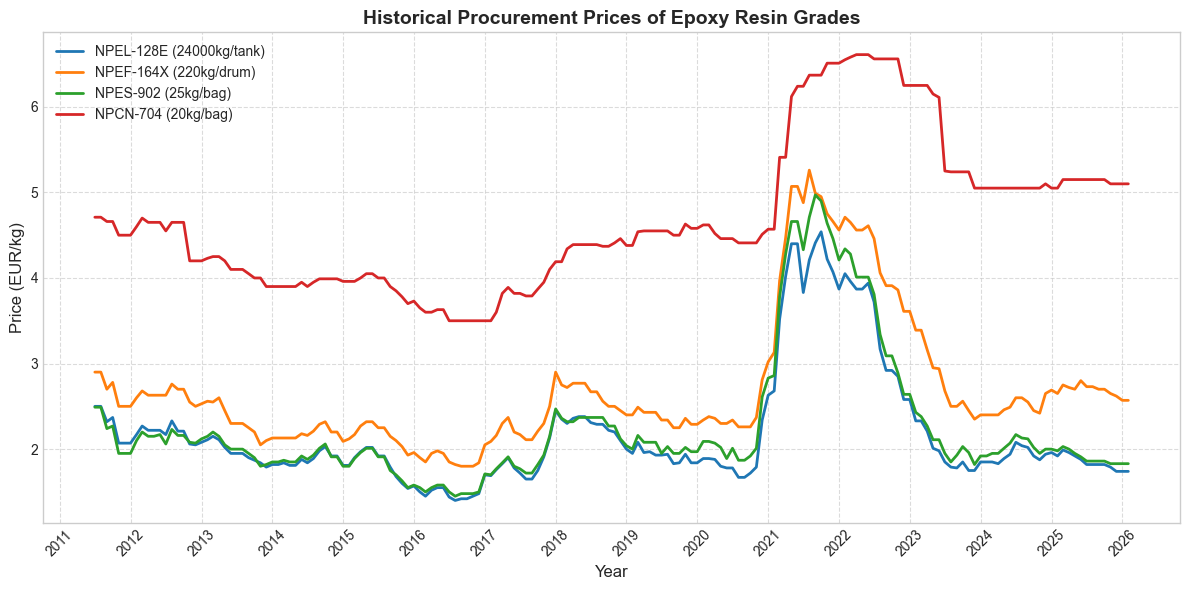

In [8]:
fig1, ax1 = plt.subplots(figsize=(12, 6))

# Plot each product line
for col in product_cols:
    ax1.plot(df['Date'], df[col], label=col, linewidth=2)

ax1.set_title('Historical Procurement Prices of Epoxy Resin Grades', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Price (EUR/kg)', fontsize=12)
ax1.legend(loc='upper left')

# Format the x-axis to show years cleanly
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()

ax1.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Plot 3: Physical vs Financial

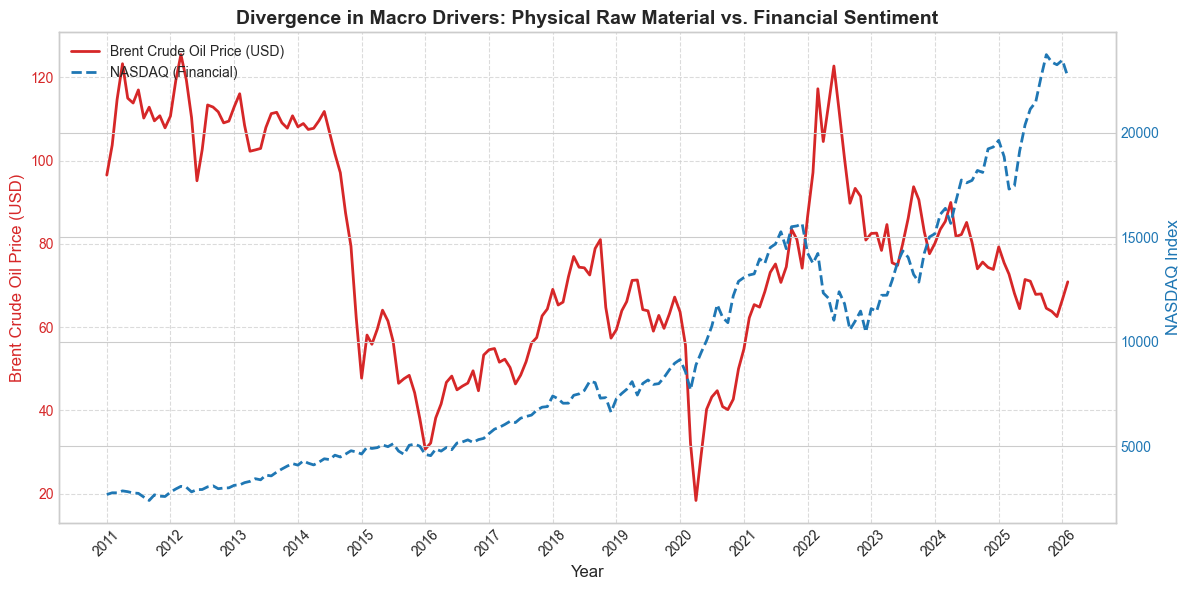

In [9]:
fig3, ax3a = plt.subplots(figsize=(12, 6))

# Plot Physical Indicator (Left Y-Axis)
color1 = 'tab:red'
ax3a.set_xlabel('Year', fontsize=12)
ax3a.set_ylabel('Brent Crude Oil Price (USD)', color=color1, fontsize=12)
line1 = ax3a.plot(df['Date'], df['Brent Crude Oil Price (USD)'], color=color1, label='Brent Crude Oil Price (USD)', linewidth=2)
ax3a.tick_params(axis='y', labelcolor=color1)

# Create a twin axis sharing the same x-axis
ax3b = ax3a.twinx()  

# Plot Financial Sentiment Indicator (Right Y-Axis)
color2 = 'tab:blue'
ax3b.set_ylabel('NASDAQ Index', color=color2, fontsize=12)
line2 = ax3b.plot(df['Date'], df['NASDAQ'], color=color2, label='NASDAQ (Financial)', linewidth=2, linestyle='--')
ax3b.tick_params(axis='y', labelcolor=color2)

# Format the x-axis
ax3a.xaxis.set_major_locator(mdates.YearLocator())
ax3a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax3a.xaxis.get_majorticklabels(), rotation=45)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3a.legend(lines, labels, loc='upper left')

plt.title('Divergence in Macro Drivers: Physical Raw Material vs. Financial Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()

ax3a.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Plot 2: Correlation heatmap

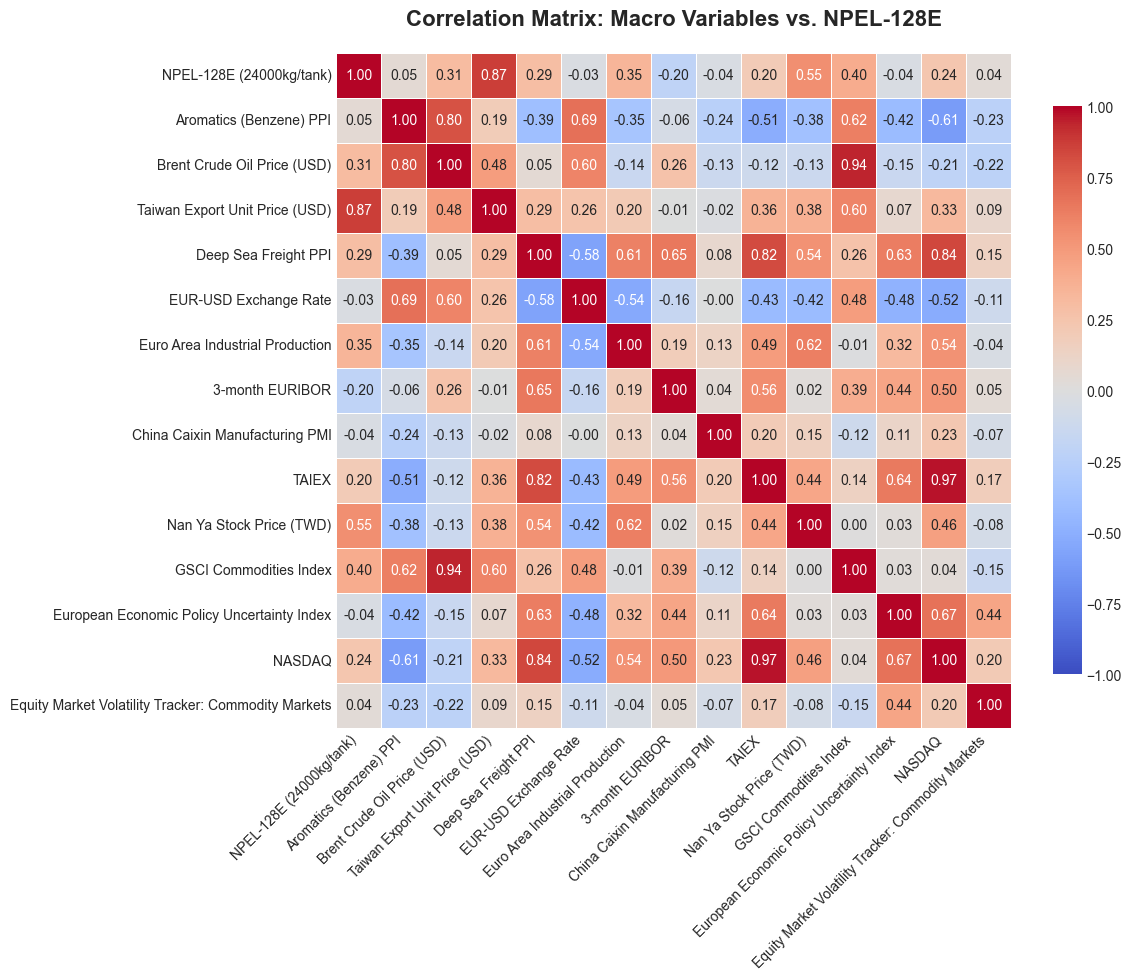

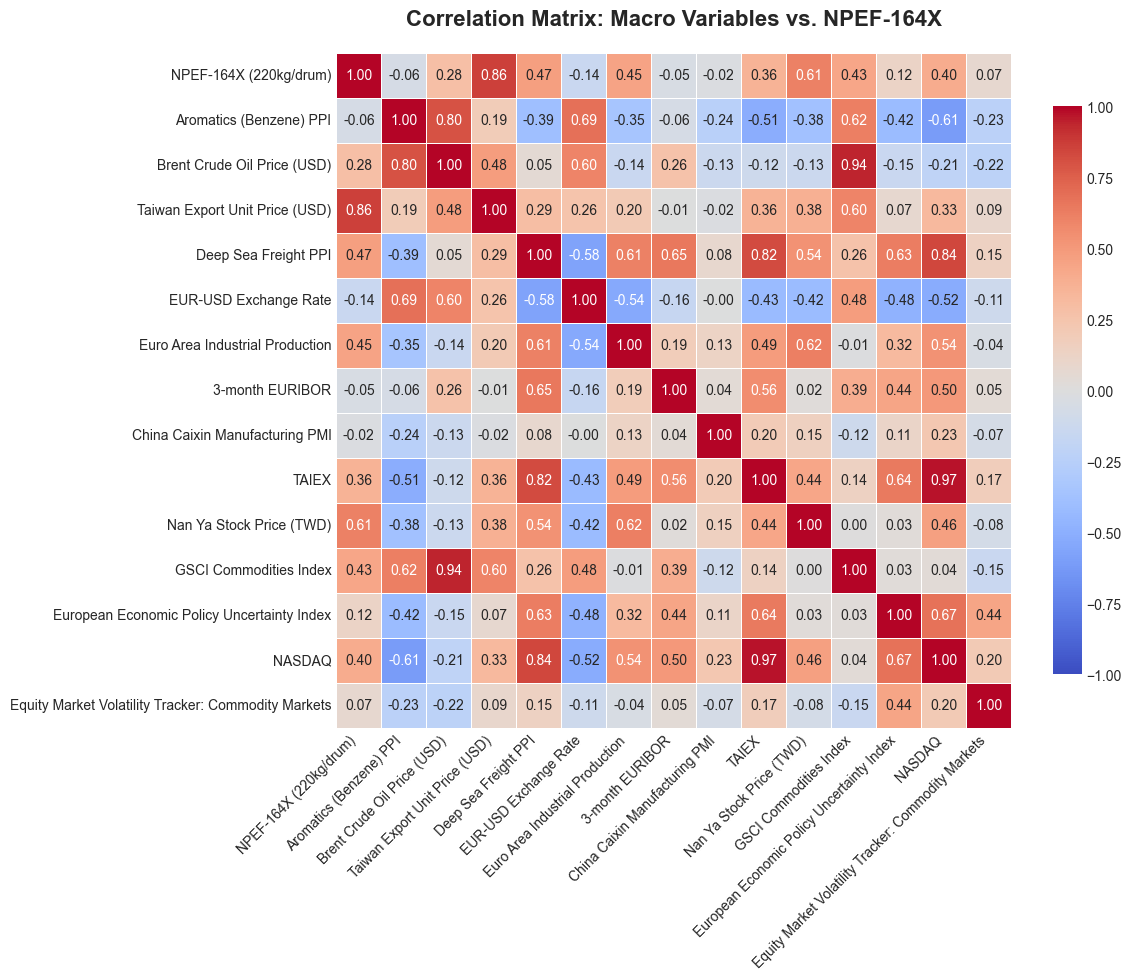

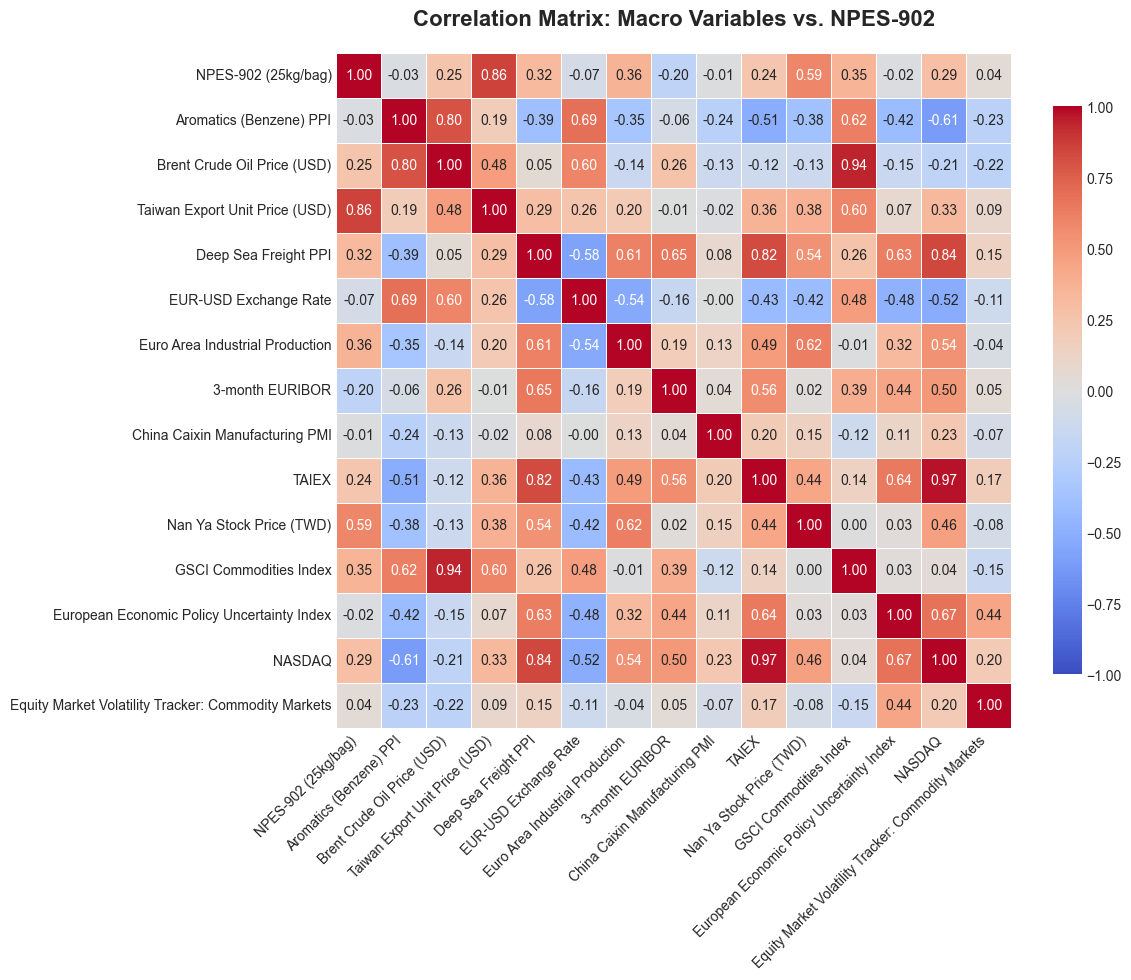

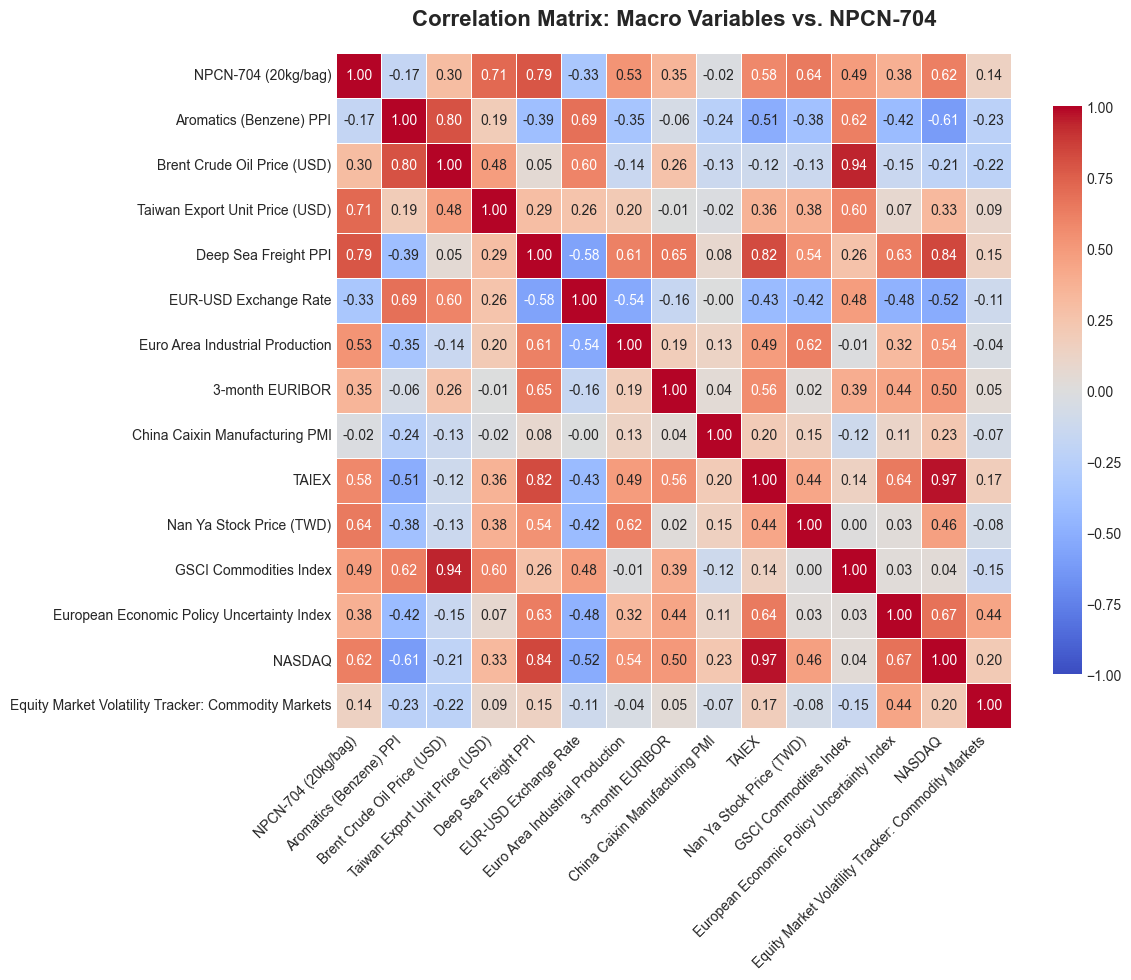

In [10]:
def generate_grade_heatmap(target_grade, data, macro_variables):
    # Combine the single target grade with the macro list
    heatmap_cols = [target_grade] + macro_variables
    
    # Calculate correlation matrix
    corr_matrix = data[heatmap_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))

    sns.heatmap(
        corr_matrix, 
        annot=True,              
        cmap='coolwarm',         
        fmt=".2f",               
        vmin=-1, vmax=1,         
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .8}, 
        ax=ax,
        annot_kws={"size": 10}   
    )

    # Extract just the grade name (e.g., "NPEL-128E") for a cleaner title and filename
    clean_grade_name = target_grade.split(' ')[0] 

    # Dynamic Title
    ax.set_title(f'Correlation Matrix: Macro Variables vs. {clean_grade_name}', 
                 fontsize=16, fontweight='bold', pad=20)
    
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    plt.show()
    
    filename = f'correlation_{clean_grade_name}.png'
    fig.savefig(filename, dpi=300)
    plt.close(fig)

# Execute the loop to generate heatmaps for all 4 grades
for grade in product_cols:
    generate_grade_heatmap(grade, df, macro_cols)

### Plot 2.5: Correlation heatmap - Everything

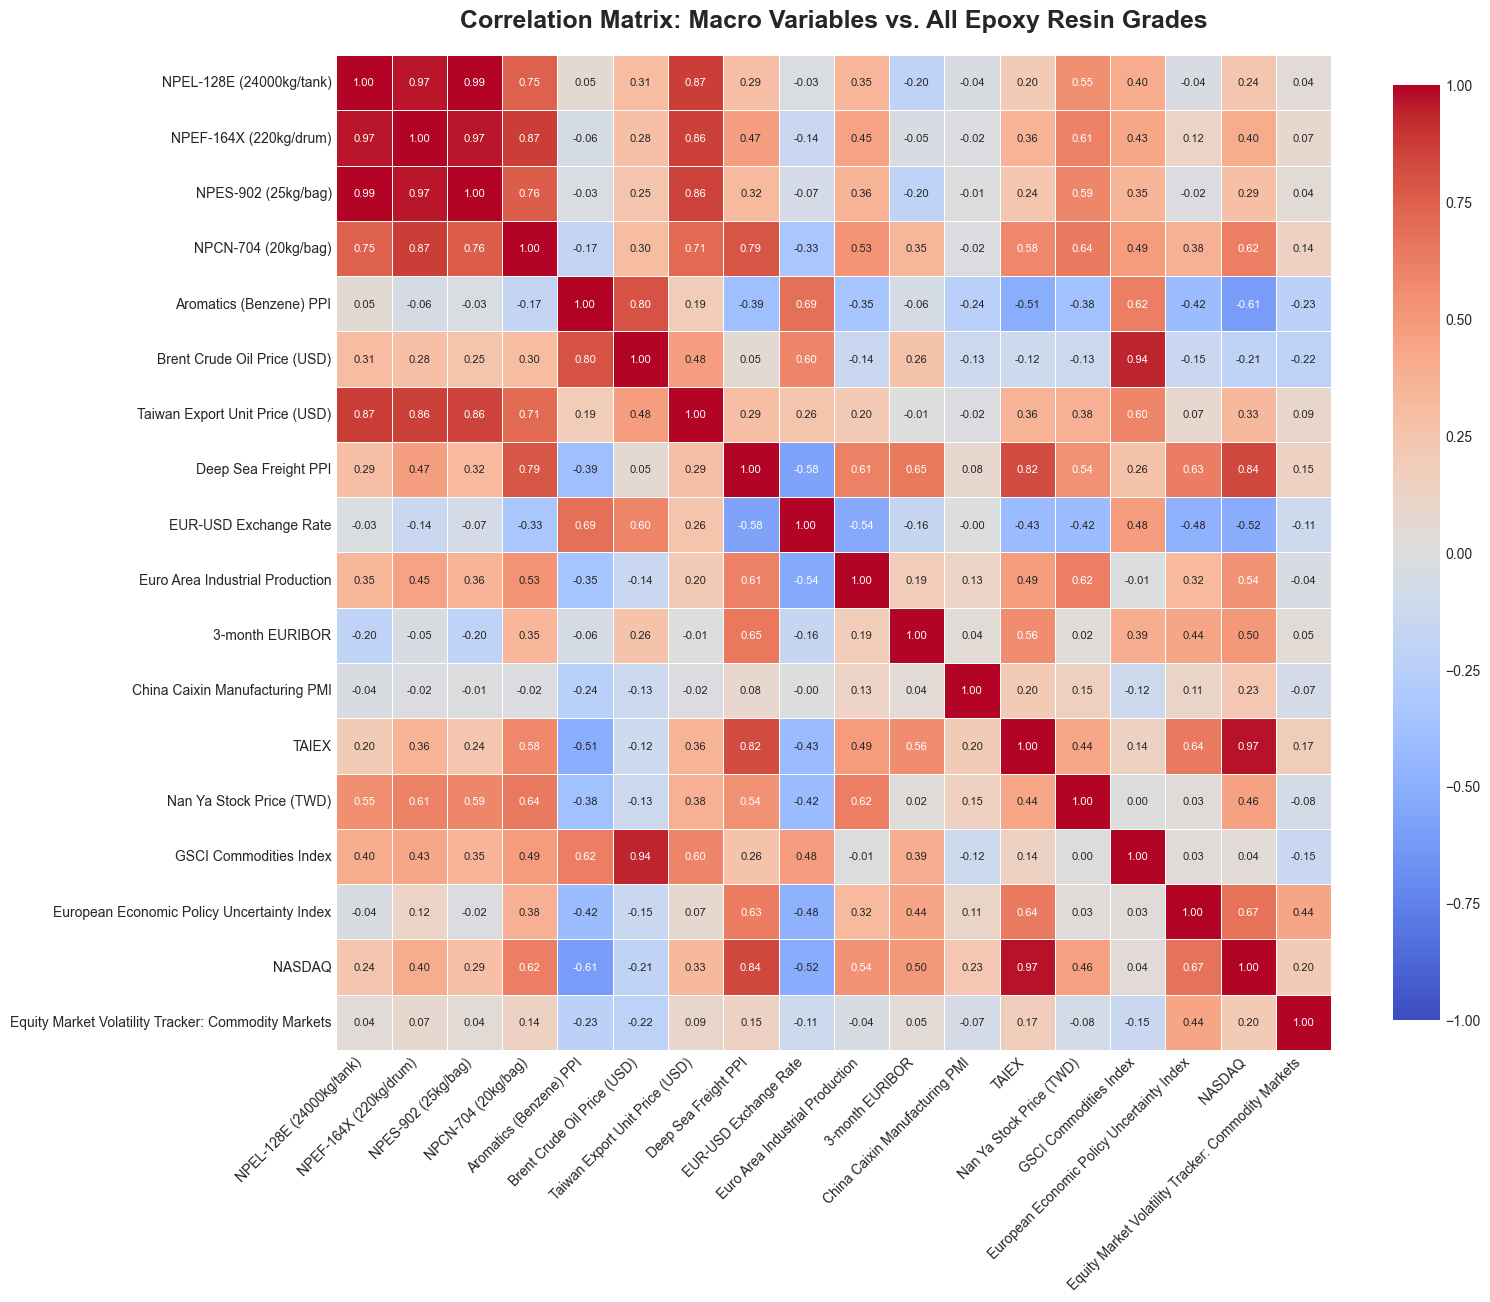

In [11]:
heatmap_cols = [
    'NPEL-128E (24000kg/tank)', 
    'NPEF-164X (220kg/drum)', 
    'NPES-902 (25kg/bag)', 
    'NPCN-704 (20kg/bag)',
    'Aromatics (Benzene) PPI', 
    'Brent Crude Oil Price (USD)', 
    'Taiwan Export Unit Price (USD)',
    'Deep Sea Freight PPI', 
    'EUR-USD Exchange Rate', 
    'Euro Area Industrial Production',
    '3-month EURIBOR', 
    'China Caixin Manufacturing PMI', 
    'TAIEX',
    'Nan Ya Stock Price (TWD)', 
    'GSCI Commodities Index',
    'European Economic Policy Uncertainty Index', 
    'NASDAQ',
    'Equity Market Volatility Tracker: Commodity Markets'
]

# Calculate the Pearson correlation matrix
corr_matrix = df[heatmap_cols].corr()

# Increased figure size (16, 14) to accommodate the larger grid
fig2, ax2 = plt.subplots(figsize=(16, 14))

# Generate the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,              
    cmap='coolwarm',         
    fmt=".2f",               
    vmin=-1, vmax=1,         
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}, 
    ax=ax2,
    annot_kws={"size": 8}    
)

ax2.set_title('Correlation Matrix: Macro Variables vs. All Epoxy Resin Grades', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.show()

In [12]:
fig2.savefig('2_heatmap_everything.png', dpi=300)
plt.close(fig2)

### Stationarity / unit-root tests (Appendix J)

In [13]:
raw = pd.read_excel('Full Data.xlsx', parse_dates=['Date']).set_index('Date')
for name in [c for c in raw.columns if c not in target_cols]:
    s = raw[name].dropna()
    adf_p = adfuller(s, autolag='AIC')[1]
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore"); kpss_p = kpss(s, regression='c', nlags='auto')[1]
    print(f"{name:35s} ADF p={adf_p:.3f}  KPSS p={kpss_p:.3f}")

NPEL-128E (24000kg/tank)            ADF p=0.062  KPSS p=0.100
NPEF-164X (220kg/drum)              ADF p=0.224  KPSS p=0.046
NPES-902 (25kg/bag)                 ADF p=0.074  KPSS p=0.100
NPCN-704 (20kg/bag)                 ADF p=0.616  KPSS p=0.010
Aromatics (Benzene) PPI             ADF p=0.176  KPSS p=0.010
Brent Crude Oil Price (USD)         ADF p=0.233  KPSS p=0.049
Taiwan Export Unit Price (USD)      ADF p=0.171  KPSS p=0.100
Deep Sea Freight PPI                ADF p=0.879  KPSS p=0.010
EUR-USD Exchange Rate               ADF p=0.039  KPSS p=0.010
Euro Area Industrial Production     ADF p=0.066  KPSS p=0.010
3-month EURIBOR                     ADF p=0.146  KPSS p=0.019
China Caixin Manufacturing PMI      ADF p=0.000  KPSS p=0.092
TAIEX                               ADF p=1.000  KPSS p=0.010
Nan Ya Stock Price (TWD)            ADF p=0.291  KPSS p=0.010
GSCI Commodities Index              ADF p=0.260  KPSS p=0.097
European Economic Policy Uncertainty Index ADF p=0.821  KPSS p=0.010
N

In [14]:
raw = pd.read_excel('Full Data.xlsx', parse_dates=['Date']).set_index('Date').sort_index()

for name in raw.columns:                      # targets + macros
    s = raw[name].diff().dropna()             # FIRST DIFFERENCE
    adf_p = adfuller(s, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(s, regression='c', nlags='auto')[1]
    ok = (adf_p < 0.05) and (kpss_p > 0.05)
    print(f"{name:38s} Δ: ADF p={adf_p:.3f}  KPSS p={kpss_p:.3f}  "
          f"-> {'stationary (I(1) confirmed)' if ok else 'check'}")

NPEL-128E (24000kg/tank)               Δ: ADF p=0.005  KPSS p=0.100  -> stationary (I(1) confirmed)
NPEF-164X (220kg/drum)                 Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
NPES-902 (25kg/bag)                    Δ: ADF p=0.001  KPSS p=0.100  -> stationary (I(1) confirmed)
NPCN-704 (20kg/bag)                    Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
Aromatics (Benzene) PPI                Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
Brent Crude Oil Price (USD)            Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
Taiwan Export Unit Price (USD)         Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
Deep Sea Freight PPI                   Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
EUR-USD Exchange Rate                  Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)
Euro Area Industrial Production        Δ: ADF p=0.000  KPSS p=0.100  -> stationary (I(1) confirmed)


## 4. Model and analysis functions
*Run all cells in this section before the Results section.*

In [15]:
# Macro-only feature set (excludes the four target *_lag1 anchors), to match the "macro only" baseline used in Section 4.1.
def macro_only_features(feature_cols, target_cols):
    return [c for c in feature_cols
            if not any(c.startswith(t) for t in target_cols)]

In [16]:
def generate_master_parallel_baseline(df, target_cols, feature_cols, train_ratio=0.8):
    # 1. Enforce stationarity across all targets
    df_stat = df.copy()
    for col in target_cols:
        df_stat[f"{col}_diff"] = df_stat[col].diff()
    df_stat.dropna(inplace=True)
    
    # 2. Train/Test split
    split_idx = int(len(df_stat) * train_ratio)
    train_df = df_stat.iloc[:split_idx]
    test_df = df_stat.iloc[split_idx:]
    
    # 3. Isolate strictly Macro Features (Blind to all resin lags)
    base_macro_features = [c for c in feature_cols if not any(t in c for t in target_cols)]
    
    results = []
    
    # Tuning grid
    param_grid = {'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.15], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}
    tscv = TimeSeriesSplit(n_splits=3)

    # 4. Loop through all 4 target variables
    for target in target_cols:
        print(f"\n--- Training Baselines for: {target} ---")
        
        y_test_actual = test_df[target]
        y_test_prev = df.shift(1).loc[y_test_actual.index][target].values
        actual_diff_signs = np.sign(test_df[f"{target}_diff"].values)
        
        # MODEL A: OLS
        ols = LinearRegression()
        ols.fit(train_df[base_macro_features], train_df[f"{target}_diff"])
        pred_ols = ols.predict(test_df[base_macro_features])
        
        results.append({
            'Target Resin': target,
            'Model Configuration': 'Multi-Variable OLS',
            'RMSE (EUR/kg)': root_mean_squared_error(y_test_actual, y_test_prev + pred_ols),
            'DA (%)': (np.sign(pred_ols) == actual_diff_signs).mean() * 100
        })

        # MODEL B: Strict XGBoost
        grid_search = GridSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'), param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid_search.fit(train_df[base_macro_features], train_df[f"{target}_diff"])
        best_model = grid_search.best_estimator_
        pred_strict = best_model.predict(test_df[base_macro_features])
        
        results.append({
            'Target Resin': target,
            'Model Configuration': 'XGBoost (Strict Grid Search)',
            'RMSE (EUR/kg)': root_mean_squared_error(y_test_actual, y_test_prev + pred_strict),
            'DA (%)': (np.sign(pred_strict) == actual_diff_signs).mean() * 100
        })

        # MODEL C: Relaxed XGBoost
        relaxed_xgb = XGBRegressor(max_depth=7, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0, random_state=42, objective='reg:squarederror')
        relaxed_xgb.fit(train_df[base_macro_features], train_df[f"{target}_diff"])
        pred_relaxed = relaxed_xgb.predict(test_df[base_macro_features])
        
        results.append({
            'Target Resin': target,
            'Model Configuration': 'XGBoost (Relaxed Heuristic)',
            'RMSE (EUR/kg)': root_mean_squared_error(y_test_actual, y_test_prev + pred_relaxed),
            'DA (%)': (np.sign(pred_relaxed) == actual_diff_signs).mean() * 100
        })

    # --- Output Table ---
    results_df = pd.DataFrame(results).round(3)
    print(results_df.to_string(index=False))
    return results_df


In [17]:
def run_sequential_study_NPEL(df, target_cols, feature_cols, train_ratio=0.8):
    
    # 1. Enforce Stationarity
    df_stat = df.copy()
    diff_targets = []
    for col in target_cols:
        diff_col = f"{col}_diff"
        df_stat[diff_col] = df_stat[col].diff()
        diff_targets.append(diff_col)
    df_stat.dropna(inplace=True)
    
    # 2. Chronological Train/Test Split
    split_idx = int(len(df_stat) * train_ratio)
    train_df = df_stat.iloc[:split_idx]
    test_df = df_stat.iloc[split_idx:]
    
    # Define features
    base_macro_features = [c for c in feature_cols if not any(t in c for t in target_cols)]
    other_resin_lags = [f"{t}_lag1" for t in target_cols if t != 'NPEL-128E']
    
    feature_tiers = {
        "Tier 1: XGBoost (Macro Only)": base_macro_features,
        "Tier 2: XGBoost (Macro + NPEL Anchor)": base_macro_features + ['NPEL-128E_lag1'],
        "Tier 3: XGBoost (Macro + Anchor + NPEF)": base_macro_features + ['NPEL-128E_lag1', other_resin_lags[0]],
        "Tier 3: XGBoost (Macro + Anchor + NPES)": base_macro_features + ['NPEL-128E_lag1', other_resin_lags[1]],
        "Tier 3: XGBoost (Macro + Anchor + NPCN)": base_macro_features + ['NPEL-128E_lag1', other_resin_lags[2]],
        "Tier 4: XGBoost (Full Cross-Learning)": base_macro_features + ['NPEL-128E_lag1'] + other_resin_lags
    }
    
    # Setup evaluation baselines
    y_test_actual = test_df['NPEL-128E']
    y_test_prev = df.shift(1).loc[y_test_actual.index]['NPEL-128E'].values
    actual_diff_signs = np.sign(test_df['NPEL-128E_diff'].values)
    
    results = []
    
    # 3. Tier 0
    ols_model = LinearRegression()
    ols_model.fit(train_df[base_macro_features], train_df['NPEL-128E_diff'])
    pred_diff_ols = ols_model.predict(test_df[base_macro_features])
    
    # Reconstruct and evaluate OLS
    abs_preds_ols = y_test_prev + pred_diff_ols
    rmse_ols = root_mean_squared_error(y_test_actual, abs_preds_ols)
    da_ols = (np.sign(pred_diff_ols) == actual_diff_signs).mean() * 100
    
    results.append({
        'Tier': 'Baseline: OLS (Macro Only)',
        'Features': len(base_macro_features),
        'Optimal Depth': 'N/A',
        'RMSE (EUR/kg)': rmse_ols,
        'DA (%)': da_ols
    })

    # 4. XGBoost tiers with tuning at each step
    param_grid = {
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    tscv = TimeSeriesSplit(n_splits=3)
    
    for tier_name, active_features in feature_tiers.items():
        
        base_xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
        
        grid_search = GridSearchCV(
            estimator=base_xgb,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        # Train and Tune
        grid_search.fit(train_df[active_features], train_df['NPEL-128E_diff'])
        best_model = grid_search.best_estimator_
        
        # Predict & Evaluate
        pred_diff = best_model.predict(test_df[active_features])
        
        abs_preds = y_test_prev + pred_diff
        rmse = root_mean_squared_error(y_test_actual, abs_preds)
        da = (np.sign(pred_diff) == actual_diff_signs).mean() * 100
        
        results.append({
            'Tier': tier_name,
            'Features': len(active_features),
            'Optimal Depth': grid_search.best_params_['max_depth'],
            'RMSE (EUR/kg)': rmse,
            'DA (%)': da
        })
        
    results_df = pd.DataFrame(results).round(3)
    print(results_df.to_string(index=False))
    
    return results_df


In [18]:
def run_sequential_study_NPEF(df, target_cols, feature_cols, train_ratio=0.8):
    # 1. Enforce Stationarity
    df_stat = df.copy()
    diff_targets = []
    for col in target_cols:
        diff_col = f"{col}_diff"
        df_stat[diff_col] = df_stat[col].diff()
        diff_targets.append(diff_col)
    df_stat.dropna(inplace=True)
    
    # 2. Chronological Train/Test Split
    split_idx = int(len(df_stat) * train_ratio)
    train_df = df_stat.iloc[:split_idx]
    test_df = df_stat.iloc[split_idx:]
    
    # Define features for the REVERSE test
    base_macro_features = [c for c in feature_cols if not any(t in c for t in target_cols)]
    other_resin_lags = [f"{t}_lag1" for t in target_cols if t != 'NPEF-164X']
    
    feature_tiers = {
        "Tier 1: NPEF Target (Macro Only)": base_macro_features,
        "Tier 2: NPEF Target (Macro + NPEF Anchor)": base_macro_features + ['NPEF-164X_lag1'],
        "Tier 3: NPEF Target (Macro + Anchor + Bulk NPEL Lag)": base_macro_features + ['NPEF-164X_lag1', 'NPEL-128E_lag1'],
        "Tier 4: NPEF Target (Full Cross-Learning)": base_macro_features + ['NPEF-164X_lag1'] + other_resin_lags
    }
    
    # Setup evaluation baselines
    y_test_actual = test_df['NPEF-164X']
    y_test_prev = df.shift(1).loc[y_test_actual.index]['NPEF-164X'].values
    actual_diff_signs = np.sign(test_df['NPEF-164X_diff'].values)
    
    results = []
    
    # 3. Tier 0
    ols_model = LinearRegression()
    ols_model.fit(train_df[base_macro_features], train_df['NPEF-164X_diff'])
    pred_diff_ols = ols_model.predict(test_df[base_macro_features])
    
    # Reconstruct and evaluate OLS
    abs_preds_ols = y_test_prev + pred_diff_ols
    rmse_ols = root_mean_squared_error(y_test_actual, abs_preds_ols)
    da_ols = (np.sign(pred_diff_ols) == actual_diff_signs).mean() * 100
    
    results.append({
        'Tier': 'Baseline: OLS (Macro Only)',
        'Features': len(base_macro_features),
        'Optimal Depth': 'N/A',
        'RMSE (EUR/kg)': rmse_ols,
        'DA (%)': da_ols
    })

    # 4. XGBoost tiers
    param_grid = {
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    tscv = TimeSeriesSplit(n_splits=3)
    
    for tier_name, active_features in feature_tiers.items():
        print(f"\n--- Tuning {tier_name} ({len(active_features)} features) ---")
        
        base_xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
        
        grid_search = GridSearchCV(
            estimator=base_xgb,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        # Train and Tune
        grid_search.fit(train_df[active_features], train_df['NPEF-164X_diff'])
        best_model = grid_search.best_estimator_
        
        
        # Predict & Evaluate
        pred_diff = best_model.predict(test_df[active_features])
        
        abs_preds = y_test_prev + pred_diff
        rmse = root_mean_squared_error(y_test_actual, abs_preds)
        da = (np.sign(pred_diff) == actual_diff_signs).mean() * 100
        
        results.append({
            'Tier': tier_name,
            'Features': len(active_features),
            'Optimal Depth': grid_search.best_params_['max_depth'],
            'RMSE (EUR/kg)': rmse,
            'DA (%)': da
        })
        
    results_df = pd.DataFrame(results).round(3)
    print(results_df.to_string(index=False))
    
    return results_df


In [19]:
def run_sequential_study_NPES(df, target_cols, feature_cols, train_ratio=0.8):
    # 1. Enforce Stationarity
    df_stat = df.copy()
    diff_targets = []
    for col in target_cols:
        diff_col = f"{col}_diff"
        df_stat[diff_col] = df_stat[col].diff()
        diff_targets.append(diff_col)
    df_stat.dropna(inplace=True)
    
    # 2. Chronological Train/Test Split
    split_idx = int(len(df_stat) * train_ratio)
    train_df = df_stat.iloc[:split_idx]
    test_df = df_stat.iloc[split_idx:]
    
    # Define features for the REVERSE test
    base_macro_features = [c for c in feature_cols if not any(t in c for t in target_cols)]
    other_resin_lags = [f"{t}_lag1" for t in target_cols if t != 'NPES-902']
    
    feature_tiers = {
        "Tier 1: NPES Target (Macro Only)": base_macro_features,
        "Tier 2: NPES Target (Macro + NPES Anchor)": base_macro_features + ['NPES-902_lag1'],
        "Tier 3: NPES Target (Macro + Anchor + Bulk NPEL Lag)": base_macro_features + ['NPES-902_lag1', 'NPEL-128E_lag1'],
        "Tier 4: NPES Target (Full Cross-Learning)": base_macro_features + ['NPES-902_lag1'] + other_resin_lags
    }
    
    # Setup evaluation baselines
    y_test_actual = test_df['NPES-902']
    y_test_prev = df.shift(1).loc[y_test_actual.index]['NPES-902'].values
    actual_diff_signs = np.sign(test_df['NPES-902_diff'].values)
    
    results = []
    
    # 3. Tier 0
    ols_model = LinearRegression()
    ols_model.fit(train_df[base_macro_features], train_df['NPES-902_diff'])
    pred_diff_ols = ols_model.predict(test_df[base_macro_features])
    
    # Reconstruct and evaluate OLS
    abs_preds_ols = y_test_prev + pred_diff_ols
    rmse_ols = root_mean_squared_error(y_test_actual, abs_preds_ols)
    da_ols = (np.sign(pred_diff_ols) == actual_diff_signs).mean() * 100
    
    results.append({
        'Tier': 'Baseline: OLS (Macro Only)',
        'Features': len(base_macro_features),
        'Optimal Depth': 'N/A',
        'RMSE (EUR/kg)': rmse_ols,
        'DA (%)': da_ols
    })

    # 4. XGBoost tiers
    param_grid = {
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    tscv = TimeSeriesSplit(n_splits=3)
    
    for tier_name, active_features in feature_tiers.items():
        print(f"\n--- Tuning {tier_name} ({len(active_features)} features) ---")
        
        base_xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
        
        grid_search = GridSearchCV(
            estimator=base_xgb,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        # Train and Tune
        grid_search.fit(train_df[active_features], train_df['NPES-902_diff'])
        best_model = grid_search.best_estimator_
        
        
        # Predict & Evaluate
        pred_diff = best_model.predict(test_df[active_features])
        
        abs_preds = y_test_prev + pred_diff
        rmse = root_mean_squared_error(y_test_actual, abs_preds)
        da = (np.sign(pred_diff) == actual_diff_signs).mean() * 100
        
        results.append({
            'Tier': tier_name,
            'Features': len(active_features),
            'Optimal Depth': grid_search.best_params_['max_depth'],
            'RMSE (EUR/kg)': rmse,
            'DA (%)': da
        })
        
    results_df = pd.DataFrame(results).round(3)
    print(results_df.to_string(index=False))
    
    return results_df

In [20]:
def run_sequential_study_NPCN(df, target_cols, feature_cols, train_ratio=0.8):
    # 1. Enforce Stationarity
    df_stat = df.copy()
    diff_targets = []
    for col in target_cols:
        diff_col = f"{col}_diff"
        df_stat[diff_col] = df_stat[col].diff()
        diff_targets.append(diff_col)
    df_stat.dropna(inplace=True)
    
    # 2. Chronological Train/Test Split
    split_idx = int(len(df_stat) * train_ratio)
    train_df = df_stat.iloc[:split_idx]
    test_df = df_stat.iloc[split_idx:]
    
    # Define features for the REVERSE test
    base_macro_features = [c for c in feature_cols if not any(t in c for t in target_cols)]
    other_resin_lags = [f"{t}_lag1" for t in target_cols if t != 'NPCN-704']
    
    feature_tiers = {
        "Tier 1: NPCN Target (Macro Only)": base_macro_features,
        "Tier 2: NPCN Target (Macro + NPCN Anchor)": base_macro_features + ['NPCN-704_lag1'],
        "Tier 3: NPCN Target (Macro + Anchor + Bulk NPEL Lag)": base_macro_features + ['NPCN-704_lag1', 'NPEL-128E_lag1'],
        "Tier 4: NPCN Target (Full Cross-Learning)": base_macro_features + ['NPCN-704_lag1'] + other_resin_lags
    }
    
    # Setup evaluation baselines
    y_test_actual = test_df['NPCN-704']
    y_test_prev = df.shift(1).loc[y_test_actual.index]['NPCN-704'].values
    actual_diff_signs = np.sign(test_df['NPCN-704_diff'].values)
    
    results = []
    
    # 3. Tier 0
    ols_model = LinearRegression()
    ols_model.fit(train_df[base_macro_features], train_df['NPCN-704_diff'])
    pred_diff_ols = ols_model.predict(test_df[base_macro_features])
    
    # Reconstruct and evaluate OLS
    abs_preds_ols = y_test_prev + pred_diff_ols
    rmse_ols = root_mean_squared_error(y_test_actual, abs_preds_ols)
    da_ols = (np.sign(pred_diff_ols) == actual_diff_signs).mean() * 100
    
    results.append({
        'Tier': 'Baseline: OLS (Macro Only)',
        'Features': len(base_macro_features),
        'Optimal Depth': 'N/A',
        'RMSE (EUR/kg)': rmse_ols,
        'DA (%)': da_ols
    })

    # 4. XGBoost tiers
    param_grid = {
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    tscv = TimeSeriesSplit(n_splits=3)
    
    for tier_name, active_features in feature_tiers.items():
        print(f"\n--- Tuning {tier_name} ({len(active_features)} features) ---")
        
        base_xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
        
        grid_search = GridSearchCV(
            estimator=base_xgb,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        # Train and Tune
        grid_search.fit(train_df[active_features], train_df['NPCN-704_diff'])
        best_model = grid_search.best_estimator_
        
        
        # Predict & Evaluate
        pred_diff = best_model.predict(test_df[active_features])
        
        abs_preds = y_test_prev + pred_diff
        rmse = root_mean_squared_error(y_test_actual, abs_preds)
        da = (np.sign(pred_diff) == actual_diff_signs).mean() * 100
        
        results.append({
            'Tier': tier_name,
            'Features': len(active_features),
            'Optimal Depth': grid_search.best_params_['max_depth'],
            'RMSE (EUR/kg)': rmse,
            'DA (%)': da
        })
        
    results_df = pd.DataFrame(results).round(3)
    print(results_df.to_string(index=False))
    
    return results_df

In [21]:
def linear_baselines_table(df, target_cols, feature_cols, train_ratio=0.8):
    base_macro = macro_only_features(feature_cols, target_cols)
 
    df_stat = df.copy()
    for t in target_cols:
        df_stat[f"{t}_diff"] = df_stat[t].diff()
    df_stat.dropna(inplace=True)
    split_idx = int(len(df_stat) * train_ratio)
    train_df, test_df = df_stat.iloc[:split_idx], df_stat.iloc[split_idx:]
    tscv = TimeSeriesSplit(n_splits=3)
    alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
 
    def eval_diff_model(pred_diff, target):
        y_actual = test_df[target].values
        y_prev = df.shift(1).loc[test_df.index, target].values
        actual_diff = test_df[f"{target}_diff"].values
        rmse = root_mean_squared_error(y_actual, y_prev + pred_diff)
        da = (np.sign(pred_diff) == np.sign(actual_diff)).mean() * 100
        return rmse, da
 
    results = []
    for t in target_cols:
        Xtr, ytr = train_df[base_macro], train_df[f"{t}_diff"]
        Xte = test_df[base_macro]
 
        # OLS
        ols = LinearRegression().fit(Xtr, ytr)
        rmse, da = eval_diff_model(ols.predict(Xte), t)
        results.append({"Grade": t, "Model": "OLS", "RMSE": rmse, "DA (%)": da})
 
        # Ridge (scaler fit on train only, alpha via TimeSeriesSplit)
        ridge = GridSearchCV(
            Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
            {"m__alpha": alphas}, cv=tscv,
            scoring="neg_root_mean_squared_error").fit(Xtr, ytr)
        rmse, da = eval_diff_model(ridge.predict(Xte), t)
        results.append({"Grade": t, "Model": "Ridge", "RMSE": rmse, "DA (%)": da})
 
        # Lasso
        lasso = GridSearchCV(
            Pipeline([("sc", StandardScaler()), ("m", Lasso(max_iter=10000))]),
            {"m__alpha": alphas}, cv=tscv,
            scoring="neg_root_mean_squared_error").fit(Xtr, ytr)
        rmse, da = eval_diff_model(lasso.predict(Xte), t)
        results.append({"Grade": t, "Model": "Lasso", "RMSE": rmse, "DA (%)": da})
 
        # --- Naive (random walk: predicted change = 0) ---
        rmse, _ = eval_diff_model(np.zeros(len(Xte)), t)
        results.append({"Grade": t, "Model": "Naive (RW)", "RMSE": rmse,
                        "DA (%)": np.nan})  # flat forecast makes no directional call
 
    out = pd.DataFrame(results).round(3)
    print(out.to_string(index=False))
    return out

In [22]:
def arimax_table(df, target_cols, feature_cols, train_ratio=0.8,
                 p_grid=(0, 1, 2), q_grid=(0, 1, 2)):
    base_macro = macro_only_features(feature_cols, target_cols)
    df_m = df.dropna(subset=base_macro).copy()
    split_idx = int(len(df_m) * train_ratio)
 
    results, coef_dump = [], {}
    for t in target_cols:
        y = df_m[t].astype(float)
        X = df_m[base_macro].astype(float)
        y_tr, X_tr = y.iloc[:split_idx], X.iloc[:split_idx]
 
        # 1) pick (p,q) by AIC on the training set (d fixed at 1)
        best_aic, best_order = np.inf, (1, 1, 1)
        for p in p_grid:
            for q in q_grid:
                if p == 0 and q == 0:
                    continue
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        res = SARIMAX(y_tr, exog=X_tr, order=(p, 1, q),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False).fit(disp=False)
                    if res.aic < best_aic:
                        best_aic, best_order = res.aic, (p, 1, q)
                except Exception:
                    continue
 
        # 2) walk-forward one-step-ahead over the test set
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = SARIMAX(y_tr, exog=X_tr, order=best_order,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
        preds_level, prev_level, actual_level = [], [], []
        for i in range(split_idx, len(df_m)):
            x_i = X.iloc[[i]]
            fc = res.forecast(steps=1, exog=x_i)
            preds_level.append(float(fc.iloc[0]))
            prev_level.append(float(y.iloc[i - 1]))
            actual_level.append(float(y.iloc[i]))
            # extend the filter with the realised observation (no full refit)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = res.append(endog=y.iloc[[i]], exog=x_i, refit=False)
 
        preds_level = np.array(preds_level)
        prev_level = np.array(prev_level)
        actual_level = np.array(actual_level)
        rmse = root_mean_squared_error(actual_level, preds_level)
        da = (np.sign(preds_level - prev_level) ==
              np.sign(actual_level - prev_level)).mean() * 100
        results.append({"Grade": t, "Model": f"ARIMAX{best_order}",
                        "RMSE": round(rmse, 3), "DA (%)": round(da, 3)})
        coef_dump[t] = res.params  # for the appendix "explicit results"
 
    out = pd.DataFrame(results)
    print(out.to_string(index=False))
    print("\n(ARIMAX coefficients per grade are in `coef_dump` -> appendix table)")
    return out, coef_dump

In [23]:
def xgb_tuning_appendix(df, target_cols, feature_cols, train_ratio=0.8):
    base_macro = macro_only_features(feature_cols, target_cols)
 
    df_stat = df.copy()
    for t in target_cols:
        df_stat[f"{t}_diff"] = df_stat[t].diff()
    df_stat.dropna(inplace=True)
    split_idx = int(len(df_stat) * train_ratio)
    train_df = df_stat.iloc[:split_idx]
 
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    }
    tscv = TimeSeriesSplit(n_splits=3)
    relaxed = dict(max_depth=7, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0)
 
    rows = []
    for t in target_cols:
        gs = GridSearchCV(
            XGBRegressor(random_state=42, objective='reg:squarederror'),
            param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
        gs.fit(train_df[base_macro], train_df[f"{t}_diff"])
        bp = gs.best_params_
        rows.append({
            "Grade": t,
            "max_depth": bp['max_depth'],
            "learning_rate": bp['learning_rate'],
            "subsample": bp['subsample'],
            "colsample_bytree": bp['colsample_bytree'],
            "CV RMSE (diff)": round(-gs.best_score_, 4),
        })
    tuned = pd.DataFrame(rows)
    print(f"Search grid: {param_grid}")
    print(f"Relaxed/heuristic config (fixed, not searched): {relaxed}")
    print(tuned.to_string(index=False))
    return tuned

In [24]:
def generate_top10_shap_table(df, target_cols, feature_cols):
    # 1. Enforce Stationarity
    df_stat = df.copy()
    df_stat['NPEL-128E_diff'] = df_stat['NPEL-128E'].diff()
    df_stat.dropna(inplace=True)
    
    # 2. Define Full Feature Space (Macro + all portfolio lags)
    # This allows us to see how the AI ranks specialty lags against macro drivers
    X_full = df_stat[feature_cols]
    y_full = df_stat['NPEL-128E_diff']
    
    # 3. Train the descriptive historical model 
    model = XGBRegressor(max_depth=7, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0, random_state=42)
    model.fit(X_full, y_full)
    
    # 4. Extract SHAP Values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_full)
    
    # 5. Calculate Mean Absolute SHAP for Global Importance
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_summary_df = pd.DataFrame({
        'Feature': X_full.columns,
        'Mean Absolute SHAP Impact (EUR/kg)': mean_abs_shap
    })
    
    # 6. Isolate and format the Top 10
    top_10_df = shap_summary_df.sort_values(by='Mean Absolute SHAP Impact (EUR/kg)', ascending=False).head(10)
    top_10_df['Mean Absolute SHAP Impact (EUR/kg)'] = top_10_df['Mean Absolute SHAP Impact (EUR/kg)'].round(4)
    
    # Add a clean ranking column for the thesis table
    top_10_df.insert(0, 'Rank', range(1, 11))
    
    print(top_10_df.to_string(index=False))
    
    return top_10_df

In [25]:
def generate_dominance_timeline(df, target_cols, feature_cols):
    # 1. Enforce Stationarity & Prepare Data
    df_stat = df.copy()
    df_stat['NPEL-128E_diff'] = df_stat['NPEL-128E'].diff()
    df_stat.dropna(inplace=True)
    
    X_full = df_stat[feature_cols]
    y_full = df_stat['NPEL-128E_diff']
    
    # 2. Train the Model & Extract SHAP
    model = XGBRegressor(max_depth=7, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0, random_state=42)
    model.fit(X_full, y_full)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_full)
    shap_time_df = pd.DataFrame(np.abs(shap_values), index=X_full.index, columns=X_full.columns)
    
    # 3. Track the "Throne" (Top 2 Features per month)
    dominance_records = []
    for date, row in shap_time_df.iterrows():
        top_2 = row.sort_values(ascending=False).head(2)
        dominance_records.append({
            'Date': date,
            'Rank 1 Feature': top_2.index[0],
            'Rank 2 Feature': top_2.index[1]
        })
        
    dominance_df = pd.DataFrame(dominance_records)
    
    # 4. Filter for plotting: Only features that hit #1 at least once
    # This keeps the y-axis clean and focused only on the true market drivers
    rank_1_features = dominance_df['Rank 1 Feature'].unique()
    plot_df = dominance_df[dominance_df['Rank 1 Feature'].isin(rank_1_features)]
    
    # 5. Plot the Dominance Scatter Timeline
    plt.figure(figsize=(14, 8))
    
    # Plot Rank 1 as large, dark dots
    sns.scatterplot(data=plot_df, x='Date', y='Rank 1 Feature', 
                    color='#d62728', s=100, marker='o', label='Rank 1 (Primary Driver)', zorder=3)
    
    # Plot Rank 2 as smaller, lighter dots
    sns.scatterplot(data=plot_df, x='Date', y='Rank 2 Feature', 
                    color='#1f77b4', s=40, marker='s', alpha=0.6, label='Rank 2 (Secondary Driver)', zorder=2)
    
    # Aesthetics
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Dominant Macro Indicators', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4, zorder=0)
    plt.legend(loc='upper right', framealpha=1)
    
    # Highlight the 2020-2022 Supply Chain Shock
    plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2022-12-01'), color='grey', alpha=0.15)
    
    plt.tight_layout()
    plt.savefig('monthly_dominance_timeline.png', dpi=300)
    plt.show()
    
    # 6. Generate a Summary Table for the Thesis
    # Count how many total months each feature spent at Rank 1
    rank_1_counts = dominance_df['Rank 1 Feature'].value_counts().reset_index()
    rank_1_counts.columns = ['Feature', 'Months at Rank 1']
    
    rank_2_counts = dominance_df['Rank 2 Feature'].value_counts().reset_index()
    rank_2_counts.columns = ['Feature', 'Months at Rank 2']
    
    print(rank_1_counts.to_string(index=False))
    print(rank_2_counts.to_string(index=False))
    
    return dominance_df, rank_1_counts, rank_2_counts

In [26]:
def perform_full_horizon_aggregated_shap(df, target_cols, feature_cols):
    # 1. Enforce stationarity over the full dataset
    df_stat = df.copy()
    df_stat['NPEL-128E_diff'] = df_stat['NPEL-128E'].diff()
    df_stat.dropna(inplace=True)
    
    X_full = df_stat[feature_cols]
    y_full = df_stat['NPEL-128E_diff']
    
    # 2. Train the flagship historical model (using optimized 'relaxed' parameters)
    model = XGBRegressor(max_depth=7, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0, random_state=42)
    model.fit(X_full, y_full)
    
    # 3. Extract time-series SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_full)
    
    # Keep absolute values to trace magnitude of impact over time
    shap_time_df = pd.DataFrame(np.abs(shap_values), index=X_full.index, columns=X_full.columns)
    
    # 4. Safely partition the features into the three distinct domains
    physical_base = ['Brent Crude Oil Price (USD)', 'Taiwan Export Unit Price (USD)', 'Deep Sea Freight PPI', 'Euro Area Industrial Production', 'China Caixin Manufacturing PMI']
    
    autoregressive_cols = [col for col in X_full.columns if any(target in col for target in target_cols)]
    physical_cols = [col for col in X_full.columns if any(phys in col for phys in physical_base)]
    financial_cols = [col for col in X_full.columns if col not in physical_cols and col not in autoregressive_cols]
    
    # 5. Aggregate feature importance by domain per month
    rolling_shap = pd.DataFrame(index=X_full.index)
    
    # Apply a 3-month rolling average to smooth out noise and highlight long-term structural regimes
    rolling_shap['Physical Fundamentals'] = shap_time_df[physical_cols].sum(axis=1).rolling(window=3, min_periods=1).mean()
    rolling_shap['Financial Sentiment'] = shap_time_df[financial_cols].sum(axis=1).rolling(window=3, min_periods=1).mean()
    rolling_shap['Autoregressive Anchors'] = shap_time_df[autoregressive_cols].sum(axis=1).rolling(window=3, min_periods=1).mean()
    
    # 6. Plot the Regime Shift over 15 Years
    plt.figure(figsize=(14, 7))
    
    plt.plot(rolling_shap.index, rolling_shap['Physical Fundamentals'], label='Physical Fundamentals', color='#1f77b4', linewidth=2.5)
    plt.plot(rolling_shap.index, rolling_shap['Financial Sentiment'], label='Financial Sentiment', color='#d62728', linewidth=2.5)
    plt.plot(rolling_shap.index, rolling_shap['Autoregressive Anchors'], label='Portfolio Cross-Learning (Lags)', color='#7f7f7f', linewidth=1.5, linestyle=':')
    
    # Aesthetics for the thesis
    plt.ylabel('Aggregated Monthly SHAP Magnitude', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Visual marker for the COVID-19 / Supply Chain Crisis regime shift
    plt.axvspan('2020-03-01', '2022-12-01', color='grey', alpha=0.15, label='Global Supply Chain Shock')
    
    plt.tight_layout()
    plt.savefig('full_horizon_aggregated_shap.png', dpi=300)
    plt.show()
    
    return rolling_shap


## 5. Results - Section 4.1: Baseline evaluation

In [27]:
master_baseline_table = generate_master_parallel_baseline(
     df_diff, target_cols, feature_cols_diff)               # Section 4.1


--- Training Baselines for: NPEL-128E ---

--- Training Baselines for: NPEF-164X ---

--- Training Baselines for: NPES-902 ---

--- Training Baselines for: NPCN-704 ---
Target Resin          Model Configuration  RMSE (EUR/kg)  DA (%)
   NPEL-128E           Multi-Variable OLS          0.208  45.714
   NPEL-128E XGBoost (Strict Grid Search)          0.159  48.571
   NPEL-128E  XGBoost (Relaxed Heuristic)          0.171  54.286
   NPEF-164X           Multi-Variable OLS          0.183  40.000
   NPEF-164X XGBoost (Strict Grid Search)          0.123  48.571
   NPEF-164X  XGBoost (Relaxed Heuristic)          0.119  40.000
    NPES-902           Multi-Variable OLS          0.203  40.000
    NPES-902 XGBoost (Strict Grid Search)          0.123  40.000
    NPES-902  XGBoost (Relaxed Heuristic)          0.112  37.143
    NPCN-704           Multi-Variable OLS          0.196  11.429
    NPCN-704 XGBoost (Strict Grid Search)          0.168  14.286
    NPCN-704  XGBoost (Relaxed Heuristic)         

In [28]:
linear_baselines_table(df_diff, target_cols, feature_cols_diff)

    Grade      Model  RMSE  DA (%)
NPEL-128E        OLS 0.208  45.714
NPEL-128E      Ridge 0.174  42.857
NPEL-128E      Lasso 0.068  22.857
NPEL-128E Naive (RW) 0.068     NaN
NPEF-164X        OLS 0.183  40.000
NPEF-164X      Ridge 0.157  42.857
NPEF-164X      Lasso 0.100  25.714
NPEF-164X Naive (RW) 0.099     NaN
 NPES-902        OLS 0.203  40.000
 NPES-902      Ridge 0.174  37.143
 NPES-902      Lasso 0.130  37.143
 NPES-902 Naive (RW) 0.070     NaN
 NPCN-704        OLS 0.196  11.429
 NPCN-704      Ridge 0.183   8.571
 NPCN-704      Lasso 0.155   5.714
 NPCN-704 Naive (RW) 0.152     NaN


,Grade,Model,RMSE,DA (%)
0,NPEL-128E,OLS,0.208,45.714
1,NPEL-128E,Ridge,0.174,42.857
2,NPEL-128E,Lasso,0.068,22.857
3,NPEL-128E,Naive (RW),0.068,NaN
4,NPEF-164X,OLS,0.183,40.000
5,NPEF-164X,Ridge,0.157,42.857
6,NPEF-164X,Lasso,0.100,25.714
7,NPEF-164X,Naive (RW),0.099,NaN
8,NPES-902,OLS,0.203,40.000
9,NPES-902,Ridge,0.174,37.143


In [29]:
arimax_table(df_diff, target_cols, feature_cols_diff)

    Grade           Model  RMSE  DA (%)
NPEL-128E ARIMAX(2, 1, 2) 0.352  45.714
NPEF-164X ARIMAX(2, 1, 2) 0.232  42.857
 NPES-902 ARIMAX(2, 1, 2) 0.448  40.000
 NPCN-704 ARIMAX(1, 1, 2) 0.226  17.143

(ARIMAX coefficients per grade are in `coef_dump` -> appendix table)


(       Grade            Model   RMSE  DA (%)
 0  NPEL-128E  ARIMAX(2, 1, 2)  0.352  45.714
 1  NPEF-164X  ARIMAX(2, 1, 2)  0.232  42.857
 2   NPES-902  ARIMAX(2, 1, 2)  0.448  40.000
 3   NPCN-704  ARIMAX(1, 1, 2)  0.226  17.143,
 {'NPEL-128E': Brent Crude Oil Price (USD)_lag1                            0.003506
  Brent Crude Oil Price (USD)_lag2                           -0.006515
  Brent Crude Oil Price (USD)_lag3                            0.021572
  Taiwan Export Unit Price (USD)_lag1                         0.014813
  Taiwan Export Unit Price (USD)_lag2                        -0.012140
  Taiwan Export Unit Price (USD)_lag3                         0.014292
  Deep Sea Freight PPI_lag1                                  -0.005380
  Deep Sea Freight PPI_lag2                                   0.008630
  Deep Sea Freight PPI_lag3                                  -0.017677
  EUR-USD Exchange Rate_lag1                                 -0.023440
  EUR-USD Exchange Rate_lag2                  

## 5. Results - Section 4.2: Sequential Studies

### Mega as target, all others as leads

In [30]:
run_sequential_study_NPEL(df_diff, target_cols, feature_cols_diff)

                                   Tier  Features Optimal Depth  RMSE (EUR/kg)  DA (%)
             Baseline: OLS (Macro Only)        33           N/A          0.208  45.714
           Tier 1: XGBoost (Macro Only)        33             3          0.159  48.571
  Tier 2: XGBoost (Macro + NPEL Anchor)        34             3          0.138  48.571
Tier 3: XGBoost (Macro + Anchor + NPEF)        35             3          0.146  51.429
Tier 3: XGBoost (Macro + Anchor + NPES)        35             3          0.162  51.429
Tier 3: XGBoost (Macro + Anchor + NPCN)        35             3          0.143  48.571
  Tier 4: XGBoost (Full Cross-Learning)        37             3          0.168  51.429


,Tier,Features,Optimal Depth,RMSE (EUR/kg),DA (%)
0,Baseline: OLS (Macro Only),33,N/A,0.208,45.714
1,Tier 1: XGBoost (Macro Only),33,3,0.159,48.571
2,Tier 2: XGBoost (Macro + NPEL Anchor),34,3,0.138,48.571
3,Tier 3: XGBoost (Macro + Anchor + NPEF),35,3,0.146,51.429
4,Tier 3: XGBoost (Macro + Anchor + NPES),35,3,0.162,51.429
5,Tier 3: XGBoost (Macro + Anchor + NPCN),35,3,0.143,48.571
6,Tier 4: XGBoost (Full Cross-Learning),37,3,0.168,51.429


### All others as target, Mega as lead

In [31]:
run_sequential_study_NPEF(df_diff, target_cols, feature_cols_diff)
run_sequential_study_NPES(df_diff, target_cols, feature_cols_diff)
run_sequential_study_NPCN(df_diff, target_cols, feature_cols_diff)


--- Tuning Tier 1: NPEF Target (Macro Only) (33 features) ---

--- Tuning Tier 2: NPEF Target (Macro + NPEF Anchor) (34 features) ---

--- Tuning Tier 3: NPEF Target (Macro + Anchor + Bulk NPEL Lag) (35 features) ---

--- Tuning Tier 4: NPEF Target (Full Cross-Learning) (37 features) ---
                                                Tier  Features Optimal Depth  RMSE (EUR/kg)  DA (%)
                          Baseline: OLS (Macro Only)        33           N/A          0.183  40.000
                    Tier 1: NPEF Target (Macro Only)        33             3          0.123  48.571
           Tier 2: NPEF Target (Macro + NPEF Anchor)        34             3          0.112  42.857
Tier 3: NPEF Target (Macro + Anchor + Bulk NPEL Lag)        35             3          0.122  51.429
           Tier 4: NPEF Target (Full Cross-Learning)        37             5          0.137  42.857

--- Tuning Tier 1: NPES Target (Macro Only) (33 features) ---

--- Tuning Tier 2: NPES Target (Macro + NPES A

,Tier,Features,Optimal Depth,RMSE (EUR/kg),DA (%)
0,Baseline: OLS (Macro Only),33,N/A,0.196,11.429
1,Tier 1: NPCN Target (Macro Only),33,7,0.168,14.286
2,Tier 2: NPCN Target (Macro + NPCN Anchor),34,3,0.165,11.429
3,Tier 3: NPCN Target (Macro + Anchor + Bulk NPE...,35,3,0.169,11.429
4,Tier 4: NPCN Target (Full Cross-Learning),37,3,0.166,11.429


## 5. Results - Section 4.3: SHAP

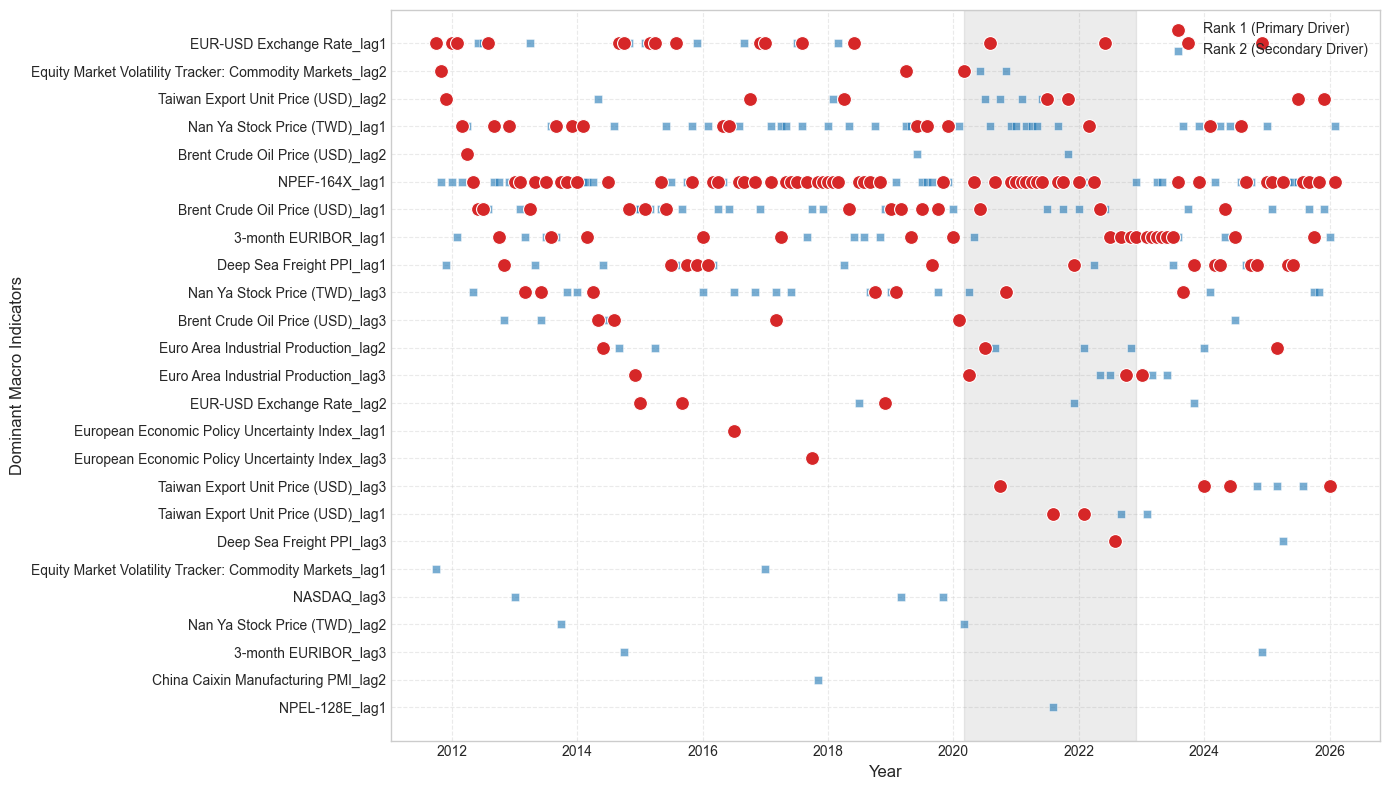

                                                 Feature  Months at Rank 1
                                          NPEF-164X_lag1                54
                                    3-month EURIBOR_lag1                19
                              EUR-USD Exchange Rate_lag1                17
                           Nan Ya Stock Price (TWD)_lag1                14
                        Brent Crude Oil Price (USD)_lag1                14
                               Deep Sea Freight PPI_lag1                14
                     Taiwan Export Unit Price (USD)_lag2                 7
                           Nan Ya Stock Price (TWD)_lag3                 7
                        Brent Crude Oil Price (USD)_lag3                 4
                    Euro Area Industrial Production_lag3                 4
                     Taiwan Export Unit Price (USD)_lag3                 4
Equity Market Volatility Tracker: Commodity Markets_lag2                 3
                    Euro 

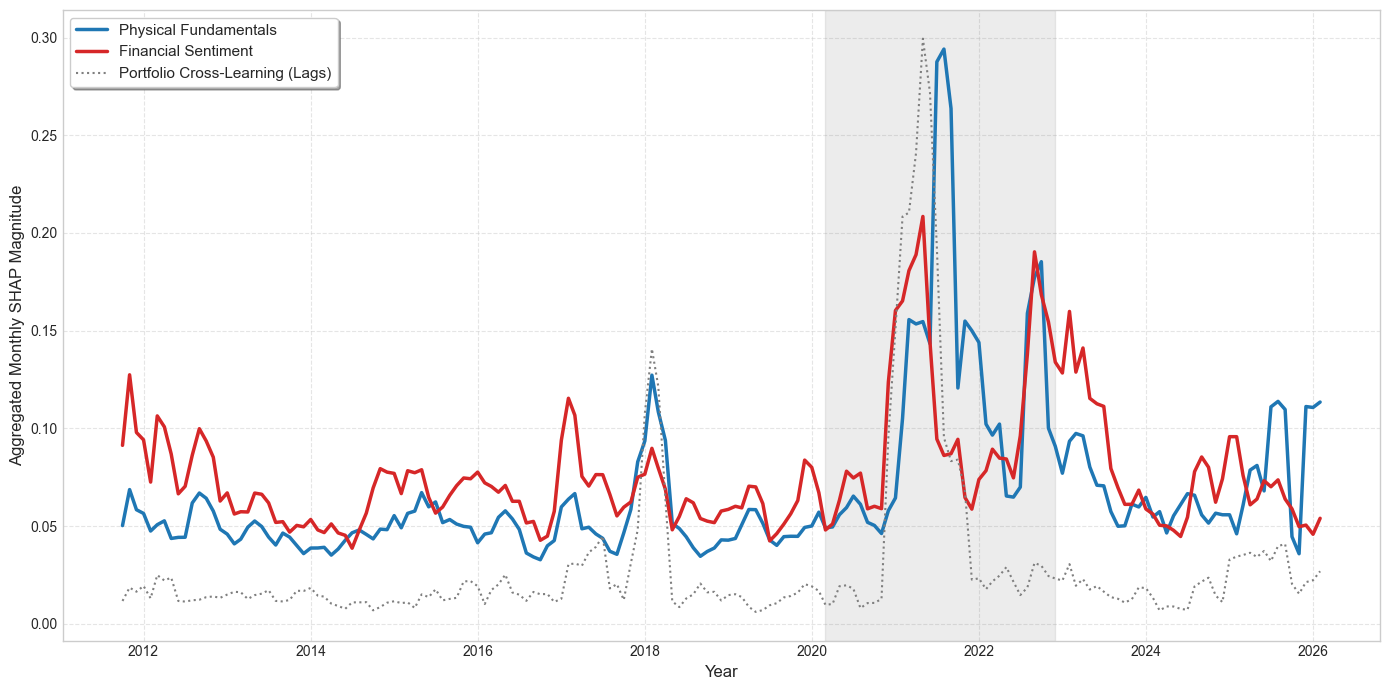

,Physical Fundamentals,Financial Sentiment,Autoregressive Anchors
Date,,,
2011-10-01,0.050216,0.091292,0.011632
2011-11-01,0.068644,0.127398,0.018477
2011-12-01,0.058340,0.097888,0.016385
2012-01-01,0.056445,0.094101,0.019325
2012-02-01,0.047433,0.072487,0.012975
...,...,...,...
2025-10-01,0.044537,0.058757,0.020394
2025-11-01,0.035805,0.049650,0.015338
2025-12-01,0.111142,0.050467,0.021272


In [32]:
generate_dominance_timeline(df_diff, target_cols, feature_cols_diff)
perform_full_horizon_aggregated_shap(df_diff, target_cols, feature_cols_diff)

In [33]:
generate_top10_shap_table(df_diff, target_cols, feature_cols_diff)

 Rank                              Feature  Mean Absolute SHAP Impact (EUR/kg)
    1                       NPEF-164X_lag1                              0.0275
    2        Nan Ya Stock Price (TWD)_lag1                              0.0172
    3                 3-month EURIBOR_lag1                              0.0135
    4  Taiwan Export Unit Price (USD)_lag2                              0.0122
    5     Brent Crude Oil Price (USD)_lag1                              0.0088
    6           EUR-USD Exchange Rate_lag1                              0.0076
    7            Deep Sea Freight PPI_lag1                              0.0075
    8        Nan Ya Stock Price (TWD)_lag3                              0.0063
    9     Brent Crude Oil Price (USD)_lag3                              0.0053
   10 Euro Area Industrial Production_lag2                              0.0050


,Rank,Feature,Mean Absolute SHAP Impact (EUR/kg)
34,1,NPEF-164X_lag1,0.0275
21,2,Nan Ya Stock Price (TWD)_lag1,0.0172
15,3,3-month EURIBOR_lag1,0.0135
4,4,Taiwan Export Unit Price (USD)_lag2,0.0122
0,5,Brent Crude Oil Price (USD)_lag1,0.0088
9,6,EUR-USD Exchange Rate_lag1,0.0076
6,7,Deep Sea Freight PPI_lag1,0.0075
23,8,Nan Ya Stock Price (TWD)_lag3,0.0063
2,9,Brent Crude Oil Price (USD)_lag3,0.0053
13,10,Euro Area Industrial Production_lag2,0.0050


## 6. Robustness: OLS with interaction terms

In [34]:
run_corrected_tiered_ols_baseline(df_diff, target_cols)

Target Resin                         OLS Configuration   RMSE  DA (%)
   NPEL-128E                        Tier 1: Macro Only 0.2076 45.7143
   NPEL-128E                    Tier 2: Macro + Anchor 0.1995 45.7143
   NPEL-128E    Tier 3: Macro + Anchor + 1 Interaction 0.1969 45.7143
   NPEL-128E Tier 4: Macro + Anchor + All Interactions 0.2027 42.8571
   NPEF-164X                        Tier 1: Macro Only 0.1831 40.0000
   NPEF-164X                    Tier 2: Macro + Anchor 0.1726 37.1429
   NPEF-164X    Tier 3: Macro + Anchor + 1 Interaction 0.1712 37.1429
   NPEF-164X Tier 4: Macro + Anchor + All Interactions 0.1745 40.0000
    NPES-902                        Tier 1: Macro Only 0.2032 40.0000
    NPES-902                    Tier 2: Macro + Anchor 0.1906 40.0000
    NPES-902    Tier 3: Macro + Anchor + 1 Interaction 0.1912 40.0000
    NPES-902 Tier 4: Macro + Anchor + All Interactions 0.1914 40.0000
    NPCN-704                        Tier 1: Macro Only 0.1961 11.4286
    NPCN-704        

,Target Resin,OLS Configuration,RMSE,DA (%)
0,NPEL-128E,Tier 1: Macro Only,0.2076,45.7143
1,NPEL-128E,Tier 2: Macro + Anchor,0.1995,45.7143
2,NPEL-128E,Tier 3: Macro + Anchor + 1 Interaction,0.1969,45.7143
3,NPEL-128E,Tier 4: Macro + Anchor + All Interactions,0.2027,42.8571
4,NPEF-164X,Tier 1: Macro Only,0.1831,40.0000
5,NPEF-164X,Tier 2: Macro + Anchor,0.1726,37.1429
6,NPEF-164X,Tier 3: Macro + Anchor + 1 Interaction,0.1712,37.1429
7,NPEF-164X,Tier 4: Macro + Anchor + All Interactions,0.1745,40.0000
8,NPES-902,Tier 1: Macro Only,0.2032,40.0000
9,NPES-902,Tier 2: Macro + Anchor,0.1906,40.0000


## 6. Robustness: Pre-COVID

### Baseline evaluation (2011-2019)

In [35]:
df_precovid_diff = df_diff.loc[:'2019-12-31'].copy()
generate_master_parallel_baseline(df_precovid_diff, target_cols, feature_cols_diff)
linear_baselines_table(df_precovid_diff, target_cols, feature_cols_diff) # Cell 4
arimax_table(df_precovid_diff, target_cols, feature_cols_diff) 


--- Training Baselines for: NPEL-128E ---

--- Training Baselines for: NPEF-164X ---

--- Training Baselines for: NPES-902 ---

--- Training Baselines for: NPCN-704 ---
Target Resin          Model Configuration  RMSE (EUR/kg)  DA (%)
   NPEL-128E           Multi-Variable OLS          0.121    50.0
   NPEL-128E XGBoost (Strict Grid Search)          0.075    50.0
   NPEL-128E  XGBoost (Relaxed Heuristic)          0.095    45.0
   NPEF-164X           Multi-Variable OLS          0.108    25.0
   NPEF-164X XGBoost (Strict Grid Search)          0.069    30.0
   NPEF-164X  XGBoost (Relaxed Heuristic)          0.079    40.0
    NPES-902           Multi-Variable OLS          0.101    35.0
    NPES-902 XGBoost (Strict Grid Search)          0.083    40.0
    NPES-902  XGBoost (Relaxed Heuristic)          0.106    35.0
    NPCN-704           Multi-Variable OLS          0.098    15.0
    NPCN-704 XGBoost (Strict Grid Search)          0.076    15.0
    NPCN-704  XGBoost (Relaxed Heuristic)         

(       Grade            Model   RMSE  DA (%)
 0  NPEL-128E  ARIMAX(1, 1, 2)  0.137    50.0
 1  NPEF-164X  ARIMAX(1, 1, 1)  0.132    25.0
 2   NPES-902  ARIMAX(0, 1, 2)  0.199    30.0
 3   NPCN-704  ARIMAX(1, 1, 0)  0.084    15.0,
 {'NPEL-128E': Brent Crude Oil Price (USD)_lag1                            0.040487
  Brent Crude Oil Price (USD)_lag2                            0.000745
  Brent Crude Oil Price (USD)_lag3                            0.014557
  Taiwan Export Unit Price (USD)_lag1                         0.043168
  Taiwan Export Unit Price (USD)_lag2                         0.006230
  Taiwan Export Unit Price (USD)_lag3                         0.007238
  Deep Sea Freight PPI_lag1                                   0.006865
  Deep Sea Freight PPI_lag2                                   0.019582
  Deep Sea Freight PPI_lag3                                  -0.002438
  EUR-USD Exchange Rate_lag1                                 -0.005098
  EUR-USD Exchange Rate_lag2                  

### OLS with interactions

In [36]:
run_corrected_tiered_ols_baseline(df_precovid_diff, target_cols)

Target Resin                         OLS Configuration   RMSE  DA (%)
   NPEL-128E                        Tier 1: Macro Only 0.1205    50.0
   NPEL-128E                    Tier 2: Macro + Anchor 0.1213    50.0
   NPEL-128E    Tier 3: Macro + Anchor + 1 Interaction 0.1209    50.0
   NPEL-128E Tier 4: Macro + Anchor + All Interactions 0.1229    45.0
   NPEF-164X                        Tier 1: Macro Only 0.1083    25.0
   NPEF-164X                    Tier 2: Macro + Anchor 0.1084    25.0
   NPEF-164X    Tier 3: Macro + Anchor + 1 Interaction 0.1079    25.0
   NPEF-164X Tier 4: Macro + Anchor + All Interactions 0.1075    25.0
    NPES-902                        Tier 1: Macro Only 0.1008    35.0
    NPES-902                    Tier 2: Macro + Anchor 0.1010    35.0
    NPES-902    Tier 3: Macro + Anchor + 1 Interaction 0.1015    35.0
    NPES-902 Tier 4: Macro + Anchor + All Interactions 0.1061    20.0
    NPCN-704                        Tier 1: Macro Only 0.0980    15.0
    NPCN-704        

,Target Resin,OLS Configuration,RMSE,DA (%)
0,NPEL-128E,Tier 1: Macro Only,0.1205,50.0
1,NPEL-128E,Tier 2: Macro + Anchor,0.1213,50.0
2,NPEL-128E,Tier 3: Macro + Anchor + 1 Interaction,0.1209,50.0
3,NPEL-128E,Tier 4: Macro + Anchor + All Interactions,0.1229,45.0
4,NPEF-164X,Tier 1: Macro Only,0.1083,25.0
5,NPEF-164X,Tier 2: Macro + Anchor,0.1084,25.0
6,NPEF-164X,Tier 3: Macro + Anchor + 1 Interaction,0.1079,25.0
7,NPEF-164X,Tier 4: Macro + Anchor + All Interactions,0.1075,25.0
8,NPES-902,Tier 1: Macro Only,0.1008,35.0
9,NPES-902,Tier 2: Macro + Anchor,0.1010,35.0


### SHAP (2011-2019)

 Rank                                                  Feature  Mean Absolute SHAP Impact (EUR/kg)
    1                         Brent Crude Oil Price (USD)_lag1                              0.0127
    2                                Deep Sea Freight PPI_lag1                              0.0105
    3                            Nan Ya Stock Price (TWD)_lag3                              0.0101
    4                      China Caixin Manufacturing PMI_lag3                              0.0090
    5                            Nan Ya Stock Price (TWD)_lag1                              0.0061
    6                      Taiwan Export Unit Price (USD)_lag1                              0.0048
    7 Equity Market Volatility Tracker: Commodity Markets_lag1                              0.0046
    8          European Economic Policy Uncertainty Index_lag3                              0.0037
    9          European Economic Policy Uncertainty Index_lag1                              0.0035
   10     

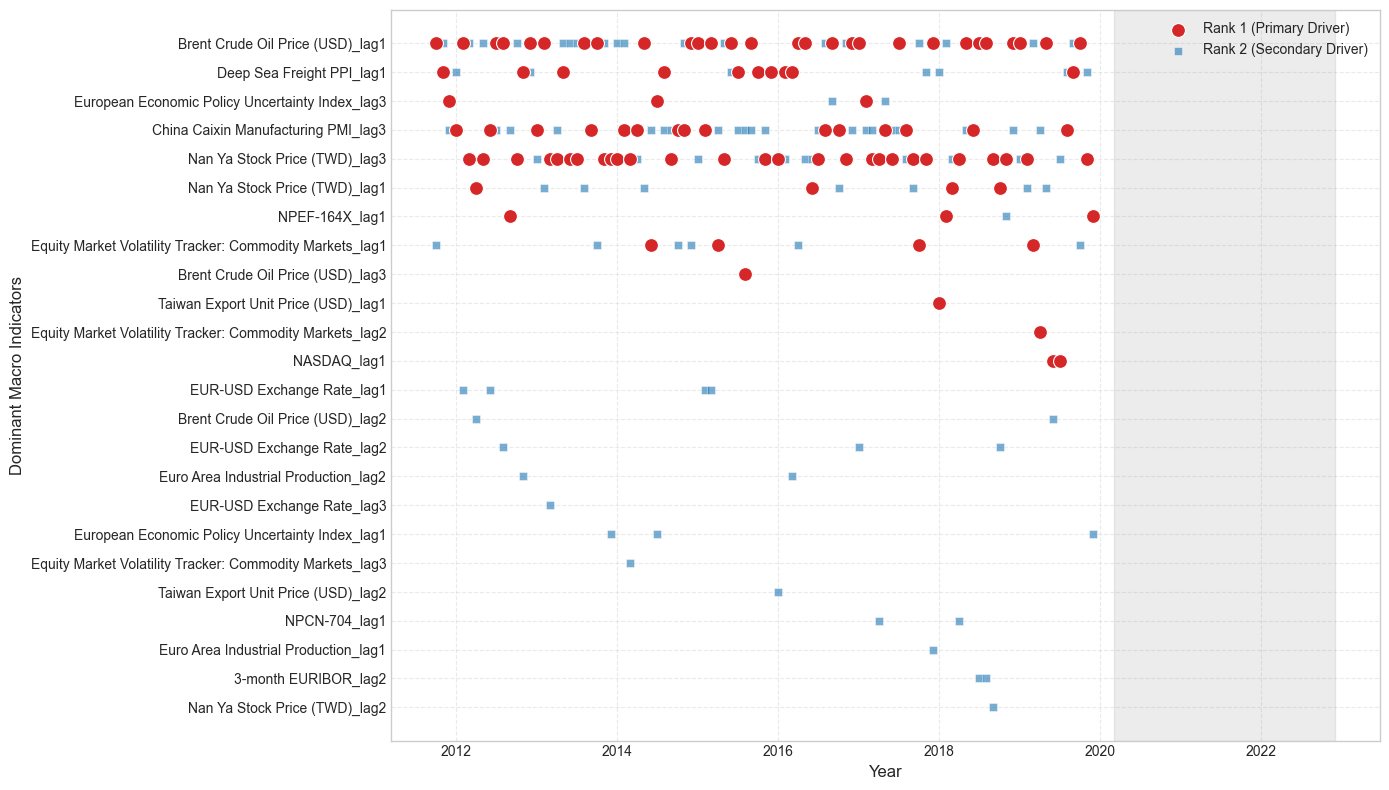

                                                 Feature  Months at Rank 1
                        Brent Crude Oil Price (USD)_lag1                28
                           Nan Ya Stock Price (TWD)_lag3                27
                     China Caixin Manufacturing PMI_lag3                15
                               Deep Sea Freight PPI_lag1                10
                           Nan Ya Stock Price (TWD)_lag1                 4
Equity Market Volatility Tracker: Commodity Markets_lag1                 4
         European Economic Policy Uncertainty Index_lag3                 3
                                          NPEF-164X_lag1                 3
                                             NASDAQ_lag1                 2
                        Brent Crude Oil Price (USD)_lag3                 1
                     Taiwan Export Unit Price (USD)_lag1                 1
Equity Market Volatility Tracker: Commodity Markets_lag2                 1
                         

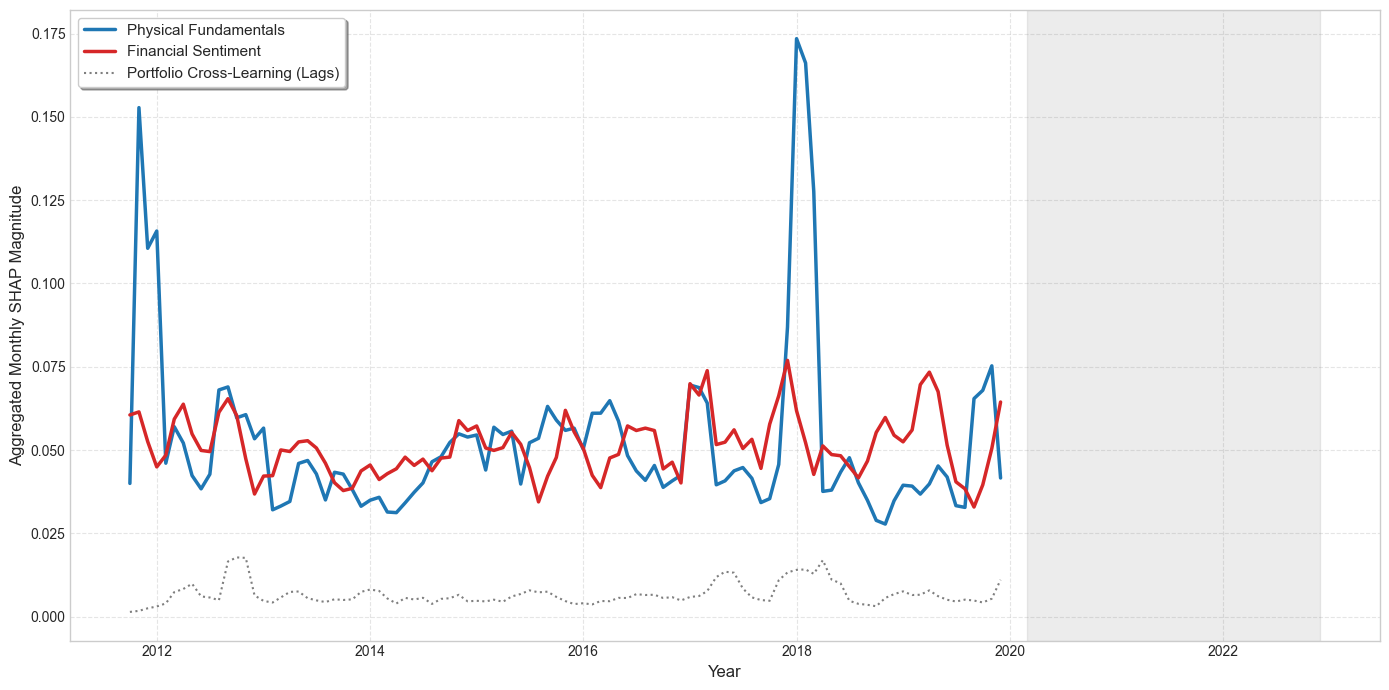

,Physical Fundamentals,Financial Sentiment,Autoregressive Anchors
Date,,,
2011-10-01,0.039978,0.060527,0.001405
2011-11-01,0.152755,0.061437,0.001726
2011-12-01,0.110545,0.052535,0.002492
2012-01-01,0.115730,0.044929,0.003027
2012-02-01,0.046037,0.048440,0.003959
...,...,...,...
2019-08-01,0.032780,0.038354,0.005092
2019-09-01,0.065435,0.032892,0.004823
2019-10-01,0.067912,0.039543,0.004238


In [37]:
generate_top10_shap_table(df_precovid_diff, target_cols, feature_cols_diff)
generate_dominance_timeline(df_precovid_diff, target_cols, feature_cols_diff)
perform_full_horizon_aggregated_shap(df_precovid_diff, target_cols, feature_cols_diff)

## Appendix: XGBoost tuning

In [38]:
xgb_tuning_appendix(df_diff, target_cols, feature_cols_diff) 

Search grid: {'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.15], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}
Relaxed/heuristic config (fixed, not searched): {'max_depth': 7, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 1.0}
    Grade  max_depth  learning_rate  subsample  colsample_bytree  CV RMSE (diff)
NPEL-128E          3           0.10        1.0               1.0          0.1451
NPEF-164X          3           0.05        0.8               0.8          0.1356
 NPES-902          3           0.05        0.8               1.0          0.1457
 NPCN-704          7           0.05        0.8               0.8          0.1191


,Grade,max_depth,learning_rate,subsample,colsample_bytree,CV RMSE (diff)
0,NPEL-128E,3,0.10,1.0,1.0,0.1451
1,NPEF-164X,3,0.05,0.8,0.8,0.1356
2,NPES-902,3,0.05,0.8,1.0,0.1457
3,NPCN-704,7,0.05,0.8,0.8,0.1191


## Appendix: VAR/VECM check

In [39]:
warnings.simplefilter("ignore")

GRADES = {                                   # display alias -> sheet short code
    'Mega-Volume':   'NPEL-128E',
    'Meso-Volume':   'NPEF-164X',
    'Micro-Volume A': 'NPES-902',
    'Micro-Volume B': 'NPCN-704',
}
DRIVERS = ['Brent Crude Oil Price (USD)',    # small, feasible driver set
           'Deep Sea Freight PPI',                # (a few top SHAP drivers)
           'EUR-USD Exchange Rate',
           'Nan Ya Stock Price (TWD)']
TRAIN_RATIO = 0.8


raw = (pd.read_excel('Full Data.xlsx', parse_dates=['Date'])
         .set_index('Date').sort_index())
raw = raw.rename(columns={c: c.split(' ')[0] for c in raw.columns
                          if c.split(' ')[0] in GRADES.values()})


def eval_target(level_pred, level_actual, level_prev):
    rmse = root_mean_squared_error(level_actual, level_pred)
    da = (np.sign(level_pred - level_prev) ==
          np.sign(level_actual - level_prev)).mean() * 100
    return round(rmse, 3), round(da, 3)


def run_system_models(short_code):
    """Johansen + VAR(diff) + VECM(levels) for one grade's small system."""
    sys_df = raw[[short_code] + DRIVERS].dropna().astype(float)
    split = int(len(sys_df) * TRAIN_RATIO)
    train, test = sys_df.iloc[:split], sys_df.iloc[split:]
    rows = []

    # 1) Johansen cointegration test (levels) -> rank at 95%
    joh = coint_johansen(train, det_order=0, k_ar_diff=1)
    rank = int(np.sum(joh.lr1 > joh.cvt[:, 1]))

    # 2) VAR on the differenced system; one-step-ahead from actual lags
    dtrain = train.diff().dropna()
    p = max(int(VAR(dtrain).select_order(maxlags=4).aic), 1)
    var_res = VAR(dtrain).fit(p)
    dsys = sys_df.diff().dropna()
    t0 = dsys.index.get_loc(test.index[0])
    preds, prevs, actuals = [], [], []
    for i in range(t0, len(dsys)):
        hist = dsys.iloc[i - p:i].values
        fc_diff = var_res.forecast(hist, steps=1)[0, 0]      # target = col 0
        prev_lvl = sys_df[short_code].iloc[
            sys_df.index.get_loc(dsys.index[i]) - 1]
        preds.append(prev_lvl + fc_diff)
        prevs.append(prev_lvl)
        actuals.append(sys_df[short_code].loc[dsys.index[i]])
    rmse, da = eval_target(np.array(preds), np.array(actuals),
                           np.array(prevs))
    rows.append({'Model': f'VAR (diff, p={p})', 'Coint. rank': rank,
                 'RMSE': rmse, 'DA': da})

    # 3) VECM on levels (only if cointegrated); indicative multi-step
    if rank >= 1:
        try:
            vecm_res = VECM(train, k_ar_diff=1, coint_rank=rank,
                            deterministic='ci').fit()
            fc = vecm_res.predict(steps=len(test))[:, 0]
            prev = sys_df[short_code].shift(1).loc[test.index].values
            rmse, da = eval_target(fc, test[short_code].values, prev)
            rows.append({'Model': f'VECM (rank={rank}, indic.)',
                         'Coint. rank': rank, 'RMSE': rmse, 'DA': da})
        except Exception as e:
            rows.append({'Model': 'VECM (failed)', 'Coint. rank': rank,
                         'RMSE': str(e)[:30], 'DA': None})
    return rows


# Run across all four grades
all_rows = []
for alias, code in GRADES.items():
    for r in run_system_models(code):
        all_rows.append({'Target Resin': alias, **r})

out = pd.DataFrame(all_rows)
print(out.to_string(index=False))

  Target Resin                 Model  Coint. rank  RMSE     DA
   Mega-Volume       VAR (diff, p=2)            1 0.131 44.444
   Mega-Volume VECM (rank=1, indic.)            1 0.489 22.222
   Meso-Volume       VAR (diff, p=2)            1 0.116 38.889
   Meso-Volume VECM (rank=1, indic.)            1 0.817 25.000
Micro-Volume A       VAR (diff, p=2)            1 0.112 36.111
Micro-Volume A VECM (rank=1, indic.)            1 0.523 25.000
Micro-Volume B       VAR (diff, p=2)            1 0.146  5.556
Micro-Volume B VECM (rank=1, indic.)            1 1.111  5.556


## Appendix: Significance tests

In [40]:
warnings.simplefilter("ignore")

_df   = globals().get('df_diff', globals().get('df_clean'))
_feat = globals().get('feature_cols_diff', globals().get('feature_cols'))
_tgt  = target_cols
assert _df is not None and _feat is not None, "Run the Differencing cells first."


def directional_da(actual_diff, pred_diff):
    """DA exactly as in the thesis: three-way sign match. A flat month
    (actual change = 0) is a miss for a continuous forecast."""
    return round(np.mean(np.sign(pred_diff) == np.sign(actual_diff)) * 100, 1)

def binomial_p(actual_diff, pred_diff):
    c = int(np.sum(np.sign(pred_diff) == np.sign(actual_diff)))
    n = len(actual_diff)
    return c, n, round(stats.binomtest(c, n, 0.5, alternative='greater').pvalue, 3)

def pesaran_timmermann(actual_diff, pred_diff):
    """PT p-value over months with a genuine non-zero move (direction = sign)."""
    a = np.asarray(actual_diff, float); p = np.asarray(pred_diff, float)
    m = a != 0
    a, p = a[m], p[m]
    n = len(a)
    if n < 3:
        return np.nan, 0
    y = (a > 0).astype(int); x = (p > 0).astype(int)
    p_hat = np.mean(x == y); py, px = y.mean(), x.mean()
    p_star = py*px + (1-py)*(1-px)
    denom = (p_star*(1-p_star)/n
             - (((2*py-1)**2)*px*(1-px)/n + ((2*px-1)**2)*py*(1-py)/n
                + 4*py*px*(1-py)*(1-px)/n**2))
    if denom <= 0 or np.isnan(denom):
        return np.nan, n
    pt = (p_hat - p_star)/np.sqrt(denom)
    return round(1 - stats.norm.cdf(pt), 3), n

def diebold_mariano(err_cand, err_base, h=1):
    d = np.asarray(err_cand) - np.asarray(err_base); n = len(d)
    if np.var(d) == 0:
        return np.nan, np.nan
    dm = (np.mean(d)/np.sqrt(np.var(d, ddof=0)/n)) * np.sqrt((n+1-2*h+h*(h-1)/n)/n)
    return round(dm, 2), round(2*(1-stats.t.cdf(abs(dm), df=n-1)), 3)


base_macro = [c for c in _feat if not any(t in c for t in _tgt)]
ds = _df.copy()
for t in _tgt: ds[f"{t}_diff"] = ds[t].diff()
ds = ds.dropna()
split = int(len(ds)*0.8)
tr, te = ds.iloc[:split], ds.iloc[split:]
tscv = TimeSeriesSplit(n_splits=3)
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
grid = {'max_depth':[3,5,7], 'learning_rate':[0.05,0.1,0.15],
        'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0]}

sig_rows, dm_rows = [], []
for t in _tgt:
    Xtr, ytr, Xte = tr[base_macro], tr[f"{t}_diff"], te[base_macro]
    adiff = te[f"{t}_diff"].values
    preds = {}
    preds['OLS']   = LinearRegression().fit(Xtr, ytr).predict(Xte)
    preds['Ridge'] = GridSearchCV(Pipeline([("sc",StandardScaler()),("m",Ridge())]),
                        {"m__alpha":alphas}, cv=tscv,
                        scoring="neg_root_mean_squared_error").fit(Xtr,ytr).predict(Xte)
    preds['Lasso'] = GridSearchCV(Pipeline([("sc",StandardScaler()),("m",Lasso(max_iter=10000))]),
                        {"m__alpha":alphas}, cv=tscv,
                        scoring="neg_root_mean_squared_error").fit(Xtr,ytr).predict(Xte)
    preds['XGBoost (tuned)'] = GridSearchCV(
                        XGBRegressor(random_state=42, objective='reg:squarederror'),
                        grid, cv=tscv, scoring='neg_root_mean_squared_error',
                        n_jobs=-1).fit(Xtr,ytr).best_estimator_.predict(Xte)
    preds['XGBoost (relaxed)'] = XGBRegressor(max_depth=7, learning_rate=0.05,
                        subsample=1.0, colsample_bytree=1.0, random_state=42,
                        objective='reg:squarederror').fit(Xtr,ytr).predict(Xte)

    # ARIMAX walk-forward (one-step) -> as a differenced prediction
    dm_ = _df.dropna(subset=base_macro).copy(); s2 = int(len(dm_)*0.8)
    y, X = dm_[t].astype(float), dm_[base_macro].astype(float)
    ytr2, Xtr2 = y.iloc[:s2], X.iloc[:s2]
    best_aic, best_order = np.inf, (1,1,1)
    for p in (0,1,2):
        for q in (0,1,2):
            if p==0 and q==0: continue
            try:
                r = SARIMAX(ytr2, exog=Xtr2, order=(p,1,q), enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
                if r.aic < best_aic: best_aic, best_order = r.aic, (p,1,q)
            except Exception: pass
    r = SARIMAX(ytr2, exog=Xtr2, order=best_order, enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False)
    a_pred_diff, a_actual_diff = [], []
    for i in range(s2, len(dm_)):
        xi = X.iloc[[i]]
        a_pred_diff.append(float(r.forecast(steps=1, exog=xi).iloc[0]) - float(y.iloc[i-1]))
        a_actual_diff.append(float(y.iloc[i]) - float(y.iloc[i-1]))
        r = r.append(endog=y.iloc[[i]], exog=xi, refit=False)
    arimax_name = f'ARIMAX{best_order}'
    preds[arimax_name] = np.array(a_pred_diff)

    # significance rows (DA strict; PT on genuine moves)
    for name, pdiff in preds.items():
        ad = np.asarray(a_actual_diff if name.startswith('ARIMAX') else adiff, float)
        da = directional_da(ad, pdiff)
        c, n, bp = binomial_p(ad, pdiff)
        pt_p, n_moves = pesaran_timmermann(ad, pdiff)
        rmse = root_mean_squared_error(ad, pdiff)
        mask = ad != 0
        da_moves = directional_da(ad[mask], pdiff[mask]) if mask.sum() else np.nan
        sig_rows.append({'Grade': t, 'Model': name, 'DA %': da, 'DA% moves': da_moves,
                         'correct': f"{c}/{n}", 'moves': n_moves,
                         'PT p': pt_p, 'binom p': bp, 'RMSE(diff)': round(rmse,3)})

    # DM: XGBoost (tuned) vs each baseline incl. ARIMAX, aligned on common dates
    err_series = {m: pd.Series((preds[m]-adiff)**2, index=te.index)
                  for m in ['OLS','Ridge','Lasso','XGBoost (tuned)']}
    err_series[arimax_name] = pd.Series(
        (np.array(a_pred_diff)-np.array(a_actual_diff))**2, index=dm_.index[s2:])
    for base in ['OLS','Ridge','Lasso', arimax_name]:
        a, b = err_series['XGBoost (tuned)'].align(err_series[base], join='inner')
        dmv, dmp = diebold_mariano(a.values, b.values)
        dm_rows.append({'Grade': t, 'XGBoost vs': base, 'DM*': dmv, 'p': dmp})

print("\nDirectional and error significance")
print(pd.DataFrame(sig_rows).to_string(index=False))

print("\n--- Diebold-Mariano: XGBoost (tuned) vs baselines ---")
print("(DM* < 0 => XGBoost more accurate; p < 0.05 => significant)")
print(pd.DataFrame(dm_rows).to_string(index=False))

k = next(k for k in range(len(te)+1)
         if stats.binomtest(k, len(te), 0.5, alternative='greater').pvalue < 0.05)
print(f"\nNote: on n={len(te)} months, a model needs >= {k}/{len(te)} "
      f"({100*k/len(te):.1f}%) correct to beat chance at p<0.05.")


Directional and error significance
    Grade             Model  DA %  DA% moves correct  moves  PT p  binom p  RMSE(diff)
NPEL-128E               OLS  45.7       59.3   16/35     27 0.381    0.750       0.208
NPEL-128E             Ridge  42.9       55.6   15/35     27 0.487    0.845       0.174
NPEL-128E             Lasso  22.9       29.6    8/35     27   NaN    1.000       0.068
NPEL-128E   XGBoost (tuned)  48.6       63.0   17/35     27 0.589    0.632       0.159
NPEL-128E XGBoost (relaxed)  54.3       70.4   19/35     27 0.162    0.368       0.171
NPEL-128E   ARIMAX(2, 1, 2)  45.7       59.3   16/35     27 0.162    0.750       0.352
NPEF-164X               OLS  40.0       51.9   14/35     27 0.391    0.912       0.183
NPEF-164X             Ridge  42.9       55.6   15/35     27 0.289    0.845       0.157
NPEF-164X             Lasso  25.7       33.3    9/35     27   NaN    0.999       0.100
NPEF-164X   XGBoost (tuned)  48.6       63.0   17/35     27 0.263    0.632       0.123
NPEF-16

## ADF/KPSS test for first-differenced stationary

In [41]:
from statsmodels.tsa.stattools import adfuller, kpss

raw = pd.read_excel('Full Data.xlsx', parse_dates=['Date']).set_index('Date').sort_index()

for name in raw.columns:
    s = raw[name].diff().dropna()             # FIRST DIFFERENCE
    adf_p = adfuller(s, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(s, regression='c', nlags='auto')[1]
    ok = (adf_p < 0.05) and (kpss_p > 0.05)
    print(f"{name:38s} Δ: ADF p={adf_p:.3f}  KPSS p={kpss_p:.3f}")

NPEL-128E (24000kg/tank)               Δ: ADF p=0.005  KPSS p=0.100
NPEF-164X (220kg/drum)                 Δ: ADF p=0.000  KPSS p=0.100
NPES-902 (25kg/bag)                    Δ: ADF p=0.001  KPSS p=0.100
NPCN-704 (20kg/bag)                    Δ: ADF p=0.000  KPSS p=0.100
Aromatics (Benzene) PPI                Δ: ADF p=0.000  KPSS p=0.100
Brent Crude Oil Price (USD)            Δ: ADF p=0.000  KPSS p=0.100
Taiwan Export Unit Price (USD)         Δ: ADF p=0.000  KPSS p=0.100
Deep Sea Freight PPI                   Δ: ADF p=0.000  KPSS p=0.100
EUR-USD Exchange Rate                  Δ: ADF p=0.000  KPSS p=0.100
Euro Area Industrial Production        Δ: ADF p=0.000  KPSS p=0.100
3-month EURIBOR                        Δ: ADF p=0.048  KPSS p=0.100
China Caixin Manufacturing PMI         Δ: ADF p=0.000  KPSS p=0.100
TAIEX                                  Δ: ADF p=0.051  KPSS p=0.015
Nan Ya Stock Price (TWD)               Δ: ADF p=0.635  KPSS p=0.100
GSCI Commodities Index                 Δ: ADF p=